<a href="https://colab.research.google.com/github/mbachant/Character-Complexity/blob/main/Text_Complexity_Calc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Text Complexity Analysis
#
# Inputs:
#   UTF-8 text files
#   glyph_complexity_database.pkl
#   noto_font_table.pkl
#   unicode_to_notofonts_map.pkl
#
# Output:
#   text_complexity.pkl
#
# The glyph complexity database is authoritative.
# Each text is analyzed using the pre-calculated complexity
# of each character in each selected font.

import os
import unicodedata
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from google.colab import drive, files

In [ ]:
# Install Noto fonts for each Colab runtime
!apt-get update -qq
!apt-get install -y fonts-noto -qq

In [199]:
# Set Matplotlib to use Unicode-capable Noto fonts so that characters
# from different writing systems are displayed instead of missing-glyph
# rectangles.

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Find installed Noto fonts
noto_fonts = [
    f
    for f in font_manager.findSystemFonts()
    if "Noto" in f
]

print(
    f"Noto font files found: {len(noto_fonts):,}"
)

for font_path in noto_fonts[:20]:
    print(font_path)

Noto font files found: 2,394
/usr/share/fonts/truetype/noto/NotoSerifDisplay-ExtraCondensedLight.ttf
/usr/share/fonts/truetype/noto/NotoSerifEthiopic-CondensedLight.ttf
/usr/share/fonts/truetype/noto/NotoSansHebrew-CondensedBlack.ttf
/usr/share/fonts/truetype/noto/NotoLoopedThai-ExtraCondensedBold.ttf
/usr/share/fonts/truetype/noto/NotoSansKannada-CondensedExtraLight.ttf
/usr/share/fonts/truetype/noto/NotoSansHebrew-SemiCondensedMedium.ttf
/usr/share/fonts/truetype/noto/NotoSansTeluguUI-ExtraCondensed.ttf
/usr/share/fonts/truetype/noto/NotoSansMalayalamUI-ExtraLight.ttf
/usr/share/fonts/truetype/noto/NotoSansArabicUI-ExtraBold.ttf
/usr/share/fonts/truetype/noto/NotoSerifSinhala-Medium.ttf
/usr/share/fonts/truetype/noto/NotoSansGujaratiUI-ExtraCondensedThin.ttf
/usr/share/fonts/truetype/noto/NotoSansKannadaUI-ExtraCondensedSemiBold.ttf
/usr/share/fonts/truetype/noto/NotoSansThai-Thin.ttf
/usr/share/fonts/truetype/noto/NotoSerifKhmer-CondensedSemiBold.ttf
/usr/share/fonts/truetype/noto/N

In [ ]:
# Choose input/output locations
#
# "drive"    = Google Drive
# "computer" = upload/download using your computer

input_source = "drive"
output_source = "drive"

base_dir = "/content/drive/MyDrive/Character Complexity"

text_directory_name = "udhr_all_txts"

glyph_database_filename = (
    "glyph_complexity_database.pkl"
)

font_table_filename = (
    "noto_font_table.pkl"
)

unicode_to_notofonts_map_filename = (
    "unicode_to_notofonts_map.pkl"
)

output_filename = (
    "text_complexity.pkl"
)

In [ ]:
# Paths / Mount Google Drive if needed

if input_source == "drive" or output_source == "drive":

    drive.mount(
        "/content/drive",
        force_remount=False
    )


input_dir = (
    base_dir
    if input_source == "drive"
    else "/content"
)

output_dir = (
    base_dir
    if output_source == "drive"
    else "/content"


)


glyph_database_path = os.path.join(
    base_dir,
    glyph_database_filename
)

font_table_path = os.path.join(
    base_dir,
    font_table_filename
)

unicode_to_notofonts_map_path = os.path.join(
    base_dir,
    unicode_to_notofonts_map_filename
)

output_path = os.path.join(
    output_dir,
    output_filename
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [147]:
# Load font table

if not os.path.isfile(font_table_path):

    raise FileNotFoundError(
        f"Font table not found:\n"
        f"{font_table_path}"
    )


font_table = pd.read_pickle(
    font_table_path
)

unicode_to_notofonts_map = pd.read_pickle(
    unicode_to_notofonts_map_path
)


print()

print(
    f"Fonts in font table: "
    f"{len(font_table):,}"
)

print(
    f"Characters in Unicode to Notofonts Map: "
    f"{len(unicode_to_notofonts_map):,}"
)


Fonts in font table: 2,460
Characters in Unicode to Notofonts Map: 79,029


In [148]:
# Load UTF-8 text files

if input_source == "drive":

    text_dir = os.path.join(
        base_dir,
        text_directory_name
    )

    if not os.path.isdir(text_dir):

        raise FileNotFoundError(
            f"Text directory not found:\n{text_dir}"
        )

    text_files = sorted(
        os.path.join(
            text_dir,
            filename
        )
        for filename in os.listdir(text_dir)
        if filename.endswith(".txt")
    )


elif input_source == "computer":

    print(
        "Upload the UTF-8 text files to analyze."
    )

    uploaded_texts = files.upload()

    if not uploaded_texts:

        raise ValueError(
            "No text files were uploaded."
        )

    text_files = sorted(
        os.path.join(
            "/content",
            filename
        )
        for filename in uploaded_texts
    )


else:

    raise ValueError(
        "input_source must be 'drive' or 'computer'."
    )


print()
print("TEXT FILES FOUND")
print()

for filepath in text_files:

    print(
        f"  {os.path.basename(filepath)}"
    )

print()
print(
    f"Total text files: "
    f"{len(text_files):,}"
)


TEXT FILES FOUND

  abk.txt
  acu.txt
  afk.txt
  agr.txt
  aja.txt
  ako.txt
  aln.txt
  amc.txt
  ame.txt
  amr.txt
  arl.txt
  arm.txt
  aru.txt
  arz.txt
  ass.txt
  atj.txt
  aub.txt
  auv1.txt
  aym.txt
  bba.txt
  bci.txt
  bcy.txt
  bem.txt
  bkl.txt
  blg.txt
  blu.txt
  boa.txt
  bpr.txt
  bra.txt
  brt.txt
  bsq.txt
  btb.txt
  bzc.txt
  cab.txt
  cak1.txt
  cbr.txt
  cbs.txt
  cbt.txt
  cbu.txt
  ccx.txt
  ceb.txt
  chj.txt
  chn.txt
  cic.txt
  cjd.txt
  cjk.txt
  cln.txt
  cni.txt
  coi.txt
  cot.txt
  cpp.txt
  cpu.txt
  crs.txt
  csa.txt
  czc.txt
  dag.txt
  den.txt
  dga.txt
  dinka.txt
  dns.txt
  dum.txt
  dut.txt
  dyo.txt
  edo.txt
  eml.txt
  eng.txt
  esg.txt
  est.txt
  ewe.txt
  fae.txt
  fal.txt
  fin.txt
  fji.txt
  foa.txt
  fri.txt
  frl.txt
  frn.txt
  frn1.txt
  frn2.txt
  fum.txt
  fum1.txt
  gac1.txt
  gac2.txt
  gag.txt
  gax.txt
  gej.txt
  ger.txt
  gkp1.txt
  gli1.txt
  gln.txt
  gls.txt
  grk.txt
  gua.txt
  guc.txt
  gun.txt
  hak.txt
  hat.txt


In [149]:
# Reads every text file, verifies UTF-8/NFC status, counts characters,
# and automatically creates files_to_inspect.
#
# A file is flagged if:
#   - it cannot be decoded as UTF-8
#   - it is empty or contains only whitespace
#   - it contains fewer than number_of_characters
#
# Change number_of_characters to set the minimum text length.

number_of_characters = 1000


texts = {}

verification_results = []

files_to_inspect = []


for filepath in text_files:

    filename = os.path.basename(filepath)

    language = os.path.splitext(
        filename
    )[0]


    try:

        with open(
            filepath,
            "r",
            encoding="utf-8"
        ) as f:

            text = f.read()


    except UnicodeDecodeError as e:

        verification_results.append({

            "file": filename,

            "language": language,

            "UTF8": False,

            "NFC": None,

            "characters": None,

            "unique_characters": None,

            "status":
                f"UTF-8 ERROR: {e}"

        })


        files_to_inspect.append(
            filename
        )

        continue


    is_nfc = unicodedata.is_normalized(
        "NFC",
        text
    )


    text = unicodedata.normalize(
        "NFC",
        text
    )


    character_count = len(text)

    counts = Counter(text)

    unique_character_count = len(counts)


    # Flag empty or whitespace-only files

    if not text.strip():

        verification_results.append({

            "file": filename,

            "language": language,

            "UTF8": True,

            "NFC": is_nfc,

            "characters": character_count,

            "unique_characters": 0,

            "status":
                "ERROR: empty or whitespace only"

        })


        files_to_inspect.append(
            filename
        )

        continue


    # Flag files below the minimum character threshold

    if character_count < number_of_characters:

        verification_results.append({

            "file": filename,

            "language": language,

            "UTF8": True,

            "NFC": is_nfc,

            "characters": character_count,

            "unique_characters":
                unique_character_count,

            "status":
                f"WARNING: fewer than "
                f"{number_of_characters:,} characters"

        })


        files_to_inspect.append(
            filename
        )


    else:

        verification_results.append({

            "file": filename,

            "language": language,

            "UTF8": True,

            "NFC": is_nfc,

            "characters": character_count,

            "unique_characters":
                unique_character_count,

            "status":
                "Contains text"

        })


    texts[language] = text


verification_table = pd.DataFrame(
    verification_results
)


print()
print("TEXT VERIFICATION")
print()

display(
    verification_table
)


print()
print("=" * 80)
print("FILES TO INSPECT")
print("=" * 80)
print()


if files_to_inspect:

    for filename in files_to_inspect:

        print(
            f'"{filename}",'
        )

    print()

    print(
        f"Total files to inspect: "
        f"{len(files_to_inspect):,}"
    )

else:

    print(
        "No files require inspection."
    )


TEXT VERIFICATION



,file,language,UTF8,NFC,characters,unique_characters,status
0,abk.txt,abk,True,True,11446,61,Contains text
1,acu.txt,acu,True,True,14563,55,Contains text
2,afk.txt,afk,True,True,10485,58,Contains text
3,agr.txt,agr,True,True,15139,65,Contains text
4,aja.txt,aja,True,True,9959,81,Contains text
...,...,...,...,...,...,...,...
256,uzb.txt,uzb,True,True,12307,67,Contains text
257,vmw.txt,vmw,True,False,10050,71,Contains text
258,wee.txt,wee,True,True,10491,63,Contains text
259,wls.txt,wls,True,True,10245,57,Contains text



FILES TO INSPECT

No files require inspection.


In [150]:
# Loads the language-code key and translates filenames such as
# "eng.txt" into their full language names.
#
# languages.txt format:
#     code<TAB>language name
#
# Example:
#     eng    English


language_key_path = os.path.join(
    base_dir,
    "udhr_all_txts",
    "udhr",
    "languages.txt"
)


language_key = pd.read_csv(
    language_key_path,
    sep="\t",
    header=None,
    names=[
        "language_code",
        "language_name"
    ],
    dtype=str
)


language_key = (
    language_key
    .dropna(subset=["language_code"])
    .drop_duplicates("language_code")
)


# Add language name to verification table

verification_table["language_name"] = (
    verification_table["language"]
    .map(
        language_key.set_index(
            "language_code"
        )["language_name"]
    )
)


# Put language name next to the code

verification_table = verification_table[
    [
        "file",
        "language",
        "language_name",
        "UTF8",
        "NFC",
        "characters",
        "unique_characters",
        "status"
    ]
]


display(
    verification_table
)

,file,language,language_name,UTF8,NFC,characters,unique_characters,status
0,abk.txt,abk,Abkhaz,True,True,11446,61,Contains text
1,acu.txt,acu,Achuar-Shiwiar,True,True,14563,55,Contains text
2,afk.txt,afk,Afrikaans,True,True,10485,58,Contains text
3,agr.txt,agr,Aguaruna,True,True,15139,65,Contains text
4,aja.txt,aja,Adja,True,True,9959,81,Contains text
...,...,...,...,...,...,...,...,...
256,uzb.txt,uzb,Uzbek (Latin),True,True,12307,67,Contains text
257,vmw.txt,vmw,Makua (Mozambique),True,False,10050,71,Contains text
258,wee.txt,wee,Sorbian,True,True,10491,63,Contains text
259,wls.txt,wls,Cymraeg (Welsh),True,True,10245,57,Contains text


In [151]:
# Inspect files

# Add any files you want to inspect manually.
# These are added to the automatically flagged files_to_inspect.

files_to_inspect.extend([
    "hnd.txt",
    "por.txt"
])

# Remove duplicates while preserving order

files_to_inspect = list(
    dict.fromkeys(files_to_inspect)
)


beginning_lines = 5
ending_lines = 5


for filename in files_to_inspect:

    language = os.path.splitext(
        filename
    )[0]

    text = texts.get(language)


    print()
    print(f"{'─' * 80}")
    print(f"{filename}", end="")

    if text is None:

        print("  ⚠ NOT LOADED")
        continue


    lines = text.splitlines()


    print(
        f"  |  {len(text):,} characters"
        f"  |  {len(lines):,} lines"
    )


    print(f"{'─' * 80}")


    print(
        "\n".join(
            lines[:beginning_lines]
        )
    )


    if len(lines) > beginning_lines + ending_lines:

        print("\n   ⋮\n")


    print(
        "\n".join(
            lines[-ending_lines:]
        )
    )


────────────────────────────────────────────────────────────────────────────────
hnd.txt  ⚠ NOT LOADED

────────────────────────────────────────────────────────────────────────────────
por.txt  |  11,459 characters  |  130 lines
────────────────────────────────────────────────────────────────────────────────
Declaração Universal dos Direitos do Homem
Preâmbulo
Considerando que o reconhecimento da dignidade inerente a todos os membros da família humana e dos seus direitos iguais e inalienáveis constitui o fundamento da liberdade, da justiça e da paz no mundo;

Considerando que o desconhecimento e o desprezo dos direitos do homem conduziram a actos de barbárie que revoltam a consciência da Humanidade e que o advento de um mundo em que os seres humanos sejam livres de falar e de crer, libertos do terror e da miséria, foi proclamado como a mais alta inspiração do Homem;

   ⋮


Artigo 30°
Nenhuma disposição da presente Declaração pode ser interpretada de maneira a envolver para qualquer E

In [152]:
# Manually exclude files from analysis if necessary

excluded_files = [
    "hnd.txt"
]


for filename in excluded_files:

    language = os.path.splitext(
        filename
    )[0]

    texts.pop(
        language,
        None
    )

    text_files = [
        filepath
        for filepath in text_files
        if os.path.basename(filepath) != filename
    ]


print(
    f"Excluded: "
    f"{len(excluded_files):,} files"
)

for filename in excluded_files:

    print(
        f"  {filename}"
    )


print(
    f"Files remaining: "
    f"{len(texts):,}"
)

Excluded: 1 files
  hnd.txt
Files remaining: 261


In [153]:
# Builds the character inventory for every text.
# Stops with an error if any text fails.
# Adds the full language name from language_key.

character_inventories = {}

inventory_failures = []


language_names = (
    language_key
    .set_index("language_code")["language_name"]
)


for language, text in texts.items():

    try:

        language_name = language_names.get(
            language,
            "UNKNOWN"
        )


        counts = Counter(text)

        records = []


        for character, count in counts.items():

            codepoint = ord(character)


            records.append({

                "language":
                    language,

                "language_name":
                    language_name,

                "character":
                    character,

                "codepoint":
                    codepoint,

                "unicode":
                    f"U+{codepoint:04X}",

                "unicode_name":
                    unicodedata.name(
                        character,
                        "UNKNOWN"
                    ),

                "category":
                    unicodedata.category(
                        character
                    ),

                "count":
                    count,

                "is_whitespace":
                    character.isspace()

            })


        inventory = pd.DataFrame(
            records
        )


        inventory = (
            inventory
            .sort_values(
                "count",
                ascending=False
            )
            .reset_index(drop=True)
        )


        character_inventories[
            language
        ] = inventory


    except Exception as e:

        inventory_failures.append(
            (
                language,
                type(e).__name__,
                str(e)
            )
        )


if inventory_failures:

    print(
        f"❌ CHARACTER INVENTORY FAILED — "
        f"{len(inventory_failures):,} text(s)"
    )

    for language, error_type, error in inventory_failures:

        print(
            f"  {language}: "
            f"{error_type}: {error}"
        )

    raise RuntimeError(
        "Character inventory construction failed."
    )

else:

    print(
        f"✓ CHARACTER INVENTORY COMPLETE — "
        f"{len(character_inventories):,} texts"
    )

✓ CHARACTER INVENTORY COMPLETE — 261 texts


In [154]:
# Provides a compact overview of the character composition of every text.
# Counts letters, numbers, punctuation, symbols, and whitespace separately.

inventory_summary = []


for language, inventory in character_inventories.items():

    total_characters = (
        inventory["count"].sum()
    )


    whitespace = (
        inventory.loc[
            inventory["is_whitespace"],
            "count"
        ].sum()
    )


    letters = (
        inventory.loc[
            inventory["category"].str.startswith("L"),
            "count"
        ].sum()
    )


    numbers = (
        inventory.loc[
            inventory["category"].str.startswith("N"),
            "count"
        ].sum()
    )


    punctuation = (
        inventory.loc[
            inventory["category"].str.startswith("P"),
            "count"
        ].sum()
    )


    symbols = (
        inventory.loc[
            inventory["category"].str.startswith("S"),
            "count"
        ].sum()
    )


    inventory_summary.append({

        "language":
            language,

        "language_name":
            inventory["language_name"].iloc[0],

        "unique_characters":
            len(inventory),

        "total_characters":
            total_characters,

        "letters":
            letters,

        "numbers":
            numbers,

        "punctuation":
            punctuation,

        "symbols":
            symbols,

        "whitespace":
            whitespace

    })


inventory_summary = (
    pd.DataFrame(
        inventory_summary
    )
    .sort_values(
        "language_name"
    )
    .reset_index(drop=True)
)


display(
    inventory_summary
)

,language,language_name,unique_characters,total_characters,letters,numbers,punctuation,symbols,whitespace
0,abk,Abkhaz,61,11446,9124,661,254,28,1379
1,atj,Achehnese,60,13072,10649,83,270,0,2070
2,acu,Achuar-Shiwiar,55,14563,12319,89,385,0,1770
3,aja,Adja,81,9959,7513,83,243,0,2109
4,gax,Afaan Oromo (Oromiffa),61,10781,8874,92,322,0,1493
...,...,...,...,...,...,...,...,...,...
256,ako,Wama,62,4790,3505,51,202,0,1028
257,guc,Wayuu,59,10855,8909,87,520,0,1339
258,tsw,Western Sotho/Tswana/Setswana,58,12475,9947,83,202,2,2241
259,ccx,Zhuang,63,10320,8464,38,301,0,1517


In [155]:
# Determine which Noto fonts can render every non-whitespace
# character in each text.
#
# Uses only unicode_to_notofonts_map.
# glyph_complexity_database is NOT used.


universal_fonts_by_language = {}

font_coverage_records = []


for language, inventory in character_inventories.items():

    language_name = language_names.get(
        language,
        "UNKNOWN"
    )


    non_whitespace = inventory[
        ~inventory["is_whitespace"]
    ]


    required_codepoints = set(
        non_whitespace["codepoint"]
    )


    if not required_codepoints:

        universal_fonts = set()

    else:

        universal_fonts = None


        for codepoint in required_codepoints:

            font_record = (
                unicode_to_notofonts_map.get(
                    codepoint
                )
            )


            if font_record is None:

                font_ids = set()

            elif isinstance(font_record, dict):

                font_ids = set(
                    font_record.get(
                        "font_ids",
                        []
                    )
                )

            else:

                font_ids = set(
                    font_record
                )


            if universal_fonts is None:

                universal_fonts = font_ids

            else:

                universal_fonts &= font_ids


            if not universal_fonts:

                break


        if universal_fonts is None:

            universal_fonts = set()


    universal_fonts_by_language[
        language
    ] = universal_fonts


    for font_id in sorted(
        universal_fonts
    ):

        font_coverage_records.append({

            "language":
                language,

            "language_name":
                language_name,

            "font_id":
                font_id

        })


font_coverage_table = pd.DataFrame(
    font_coverage_records,
    columns=[
        "language",
        "language_name",
        "font_id"
    ]
)


print(
    f"Texts checked: "
    f"{len(universal_fonts_by_language):,}"
)

print(
    f"Texts with at least one fully-rendering font: "
    f"{sum(bool(font_ids) for font_ids in universal_fonts_by_language.values()):,}"
)

print(
    f"Texts with zero fully-rendering fonts: "
    f"{sum(not font_ids for font_ids in universal_fonts_by_language.values()):,}"
)

print(
    f"Text × fully-rendering Noto font records: "
    f"{len(font_coverage_table):,}"
)

Texts checked: 261
Texts with at least one fully-rendering font: 259
Texts with zero fully-rendering fonts: 2
Text × fully-rendering Noto font records: 98,453


In [156]:
# Remove texts that have zero fully-rendering Noto fonts.

zero_coverage_languages = [
    language
    for language, font_ids
    in universal_fonts_by_language.items()
    if not font_ids
]


if zero_coverage_languages:

    print(
        f"Removing {len(zero_coverage_languages):,} "
        f"text(s) with zero font coverage:"
    )

    for language in zero_coverage_languages:

        print(
            f"  {language} — "
            f"{language_names.get(language, 'UNKNOWN')}"
        )


    # Remove from universal font results

    for language in zero_coverage_languages:

        universal_fonts_by_language.pop(
            language,
            None
        )


    # Remove from loaded texts

    for language in zero_coverage_languages:

        texts.pop(
            language,
            None
        )


    # Remove character inventories

    for language in zero_coverage_languages:

        character_inventories.pop(
            language,
            None
        )


    # Remove from active file list

    text_files = [
        filepath
        for filepath in text_files
        if os.path.splitext(
            os.path.basename(filepath)
        )[0]
        not in zero_coverage_languages
    ]


else:

    print(
        "No texts have zero font coverage."
    )


print(
    f"Texts remaining: {len(texts):,}"
)

print(
    f"Universal font records remaining: "
    f"{len(universal_fonts_by_language):,}"
)

Removing 2 text(s) with zero font coverage:
  arz — Arabic (Alarabia)
  kkn — Hankuko (Korean)
Texts remaining: 259
Universal font records remaining: 259


In [157]:
# Check if one Noto font can render every character in every text.
#
# Uses:
#   - universal_fonts_by_language
#   - unicode_to_notofonts_map
#   - font_table

nonempty_font_sets = [
    set(font_ids)
    for font_ids in universal_fonts_by_language.values()
    if font_ids
]


if nonempty_font_sets:

    common_universal_fonts = set.intersection(
        *nonempty_font_sets
    )

else:

    common_universal_fonts = set()


common_universal_fonts = sorted(
    common_universal_fonts
)


# Make sure font IDs have the same type for the lookup.

font_table_lookup = font_table.copy()

font_table_lookup["font_id"] = (
    font_table_lookup["font_id"]
    .astype(str)
)

common_font_ids_as_strings = [
    str(font_id)
    for font_id in common_universal_fonts
]


common_universal_font_table = (
    font_table_lookup[
        font_table_lookup["font_id"].isin(
            common_font_ids_as_strings
        )
    ][
        [
            "font_id",
            "font_name"
        ]
    ]
    .drop_duplicates()
    .sort_values("font_id")
    .reset_index(drop=True)
)


print()

print(
    f"Texts checked: "
    f"{len(universal_fonts_by_language):,}"
)

print(
    f"Texts with at least one fully-rendering font: "
    f"{sum(bool(font_ids) for font_ids in universal_fonts_by_language.values()):,}"
)

print(
    f"Texts with zero fully-rendering fonts: "
    f"{sum(not font_ids for font_ids in universal_fonts_by_language.values()):,}"
)

print(
    f"Fonts that can render every character "
    f"in every text with coverage: "
    f"{len(common_universal_fonts):,}"
)

print()

print(
    "Common universal font IDs:"
)

print(
    common_universal_fonts
)

print()

print(
    "Common universal fonts:"
)

display(
    common_universal_font_table
)


Texts checked: 259
Texts with at least one fully-rendering font: 259
Texts with zero fully-rendering fonts: 0
Fonts that can render every character in every text with coverage: 0

Common universal font IDs:
[]

Common universal fonts:


,font_id,font_name


In [158]:
# Number of Noto fonts capable of fully rendering every
# non-whitespace character in each text.

font_coverage_summary = pd.DataFrame([
    {
        "language": language,
        "language_name": language_names.get(
            language,
            "UNKNOWN"
        ),
        "fully_rendering_fonts": len(font_ids)
    }
    for language, font_ids
    in universal_fonts_by_language.items()
])


font_coverage_summary = (
    font_coverage_summary
    .sort_values(
        "fully_rendering_fonts",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    font_coverage_summary
)

,language,language_name,fully_rendering_fonts
0,zuu,Zulu,407
1,lue,Luvale,407
2,toi,Tonga,406
3,tru1,Chuuk (Trukese),406
4,tgl,Filipino (Tagalog),406
...,...,...,...
254,dum,Gonja,324
255,bra,Bambara,324
256,jpn,Japanese (Nihongo),80
257,chn,Chinese (Mandarin),80


In [159]:
# For each text, calculate how many of its fully-rendering fonts
# are also capable of rendering each other text.
#
# This identifies texts whose usable font pool overlaps strongly
# with the usable font pools of other texts.

languages = list(
    universal_fonts_by_language.keys()
)


common_font_records = []


for language in languages:

    this_fonts = set(
        universal_fonts_by_language[language]
    )


    if not this_fonts:
        continue


    shared_counts = []


    for other_language in languages:

        if other_language == language:
            continue


        other_fonts = set(
            universal_fonts_by_language[
                other_language
            ]
        )


        shared_counts.append(
            len(
                this_fonts & other_fonts
            )
        )


    common_font_records.append({

        "language":
            language,

        "language_name":
            language_names.get(
                language,
                "UNKNOWN"
            ),

        "fully_rendering_fonts":
            len(this_fonts),

        "mean_shared_fonts":
            np.mean(shared_counts),

        "median_shared_fonts":
            np.median(shared_counts),

        "maximum_shared_fonts":
            max(shared_counts),

        "texts_with_shared_fonts":
            sum(
                count > 0
                for count in shared_counts
            )

    })


common_font_summary = (
    pd.DataFrame(
        common_font_records
    )
    .sort_values(
        [
            "mean_shared_fonts",
            "texts_with_shared_fonts"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "TOP 10 TEXTS WITH THE MOST FONTS IN COMMON"
)

display(
    common_font_summary.head(10)
)

TOP 10 TEXTS WITH THE MOST FONTS IN COMMON


,language,language_name,fully_rendering_fonts,mean_shared_fonts,median_shared_fonts,maximum_shared_fonts,texts_with_shared_fonts
0,lue,Luvale,407,380.023256,405.0,407,258
1,zuu,Zulu,407,380.023256,405.0,407,258
2,atj,Achehnese,406,380.019380,405.0,406,258
3,bcy,Bichelamar,406,380.019380,405.0,406,258
4,bem,Bemba,406,380.019380,405.0,406,258
5,bkl,Bikol/Bicolano,406,380.019380,405.0,406,258
6,blu,"Hmong (Miao), Sichuan-Guizhou-Yunnan",406,380.019380,405.0,406,258
7,bpr,Bugisnese,406,380.019380,405.0,406,258
8,bsq,Basque (Euskara),406,380.019380,405.0,406,258
9,bzc,Balinese,406,380.019380,405.0,406,258


In [160]:
# Count how many texts each font can fully render.

font_usage = []

for language, font_ids in universal_fonts_by_language.items():

    for font_id in font_ids:

        font_usage.append({
            "font_id": font_id,
            "language": language
        })


font_usage = pd.DataFrame(font_usage)


font_usage_summary = (
    font_usage
    .groupby("font_id")
    .agg(
        texts_fully_rendered=("language", "nunique")
    )
    .reset_index()
    .merge(
        font_table[
            ["font_id", "font_name"]
        ].drop_duplicates("font_id"),
        on="font_id",
        how="left"
    )
    .sort_values(
        "texts_fully_rendered",
        ascending=False
    )
    .reset_index(drop=True)
)


print("TOP 10 MOST WIDELY SUPPORTED FONTS")

display(
    font_usage_summary.head(10)
)

TOP 10 MOST WIDELY SUPPORTED FONTS


,font_id,texts_fully_rendered,font_name
0,86,257,Noto Sans Mono SemiCondensed ExtraBold
1,2288,257,Noto Sans Mono Condensed Black
2,2211,257,Noto Sans Mono ExtraCondensed Thin
3,2213,257,Noto Sans Mono ExtraCondensed SemiBold
4,1671,257,Noto Sans Mono ExtraCondensed Black
5,1696,257,Noto Sans Mono Condensed ExtraLight
6,1891,257,Noto Sans Mono SemiCondensed Light
7,1444,257,Noto Sans Mono Condensed Medium
8,1344,257,Noto Sans Mono Condensed Light
9,1345,257,Noto Sans Mono Light


In [161]:
# Load glyph complexity database

if not os.path.isfile(glyph_database_path):

    raise FileNotFoundError(
        f"Glyph complexity database not found:\n"
        f"{glyph_database_path}"
    )


glyph_complexity_database = pd.read_pickle(
    glyph_database_path
)


required_columns = {
    "font_id",
    "font_name",
    "codepoint",
    "character",
    "complexity"
}


missing_columns = (
    required_columns
    - set(glyph_complexity_database.columns)
)


if missing_columns:

    raise ValueError(
        "Glyph complexity database is missing "
        f"required columns: {sorted(missing_columns)}"
    )


print("GLYPH COMPLEXITY DATABASE")
print()

print(
    f"Records: "
    f"{len(glyph_complexity_database):,}"
)

print(
    f"Fonts: "
    f"{glyph_complexity_database['font_id'].nunique():,}"
)

print(
    f"Characters: "
    f"{glyph_complexity_database['codepoint'].nunique():,}"
)

print(
    f"Non-null complexity values: "
    f"{glyph_complexity_database['complexity'].notna().sum():,}"
)

GLYPH COMPLEXITY DATABASE

Records: 58,228
Fonts: 8
Characters: 48,242
Non-null complexity values: 58,228


In [162]:
# Determine glyph-complexity coverage for every text
# across every font currently present in the glyph database.


available_fonts = (
    glyph_complexity_database[
        [
            "font_id",
            "font_name"
        ]
    ]
    .drop_duplicates()
    .sort_values("font_id")
    .reset_index(drop=True)
)


coverage_records = []


for language, inventory in character_inventories.items():

    non_whitespace = inventory[
        ~inventory["is_whitespace"]
    ]


    required_codepoints = set(
        non_whitespace["codepoint"]
    )


    for _, font_row in available_fonts.iterrows():

        font_id = font_row["font_id"]
        font_name = font_row["font_name"]


        font_records = (
            glyph_complexity_database[
                glyph_complexity_database["font_id"]
                == font_id
            ]
        )


        available_codepoints = set(
            font_records.loc[
                font_records["complexity"].notna(),
                "codepoint"
            ]
        )


        missing_codepoints = (
            required_codepoints
            - available_codepoints
        )


        renderable = (
            len(required_codepoints)
            - len(missing_codepoints)
        )


        coverage_percent = (
            100 * renderable
            / len(required_codepoints)
            if required_codepoints
            else 100.0
        )


        coverage_records.append({

            "language":
                language,

            "font_id":
                font_id,

            "font_name":
                font_name,

            "required_characters":
                len(required_codepoints),

            "renderable":
                renderable,

            "missing":
                len(missing_codepoints),

            "coverage_percent":
                coverage_percent,

            "full_coverage":
                len(missing_codepoints) == 0

        })


coverage_table = pd.DataFrame(
    coverage_records
)


print()
print("FONT COVERAGE BY TEXT")
print()

display(
    coverage_table
)


FONT COVERAGE BY TEXT



,language,font_id,font_name,required_characters,renderable,missing,coverage_percent,full_coverage
0,abk,827,Noto Sans Thai Regular,58,1,57,1.724138,False
1,abk,1050,Noto Sans Hebrew Regular,58,1,57,1.724138,False
2,abk,1344,Noto Sans Mono Condensed Light,58,58,0,100.000000,True
3,abk,1667,Noto Sans Arabic Regular,58,13,45,22.413793,False
4,abk,2142,Noto Sans CJK SC,58,58,0,100.000000,True
...,...,...,...,...,...,...,...,...
2067,zuu,1667,Noto Sans Arabic Regular,60,13,47,21.666667,False
2068,zuu,2142,Noto Sans CJK SC,60,60,0,100.000000,True
2069,zuu,2211,Noto Sans Mono ExtraCondensed Thin,60,60,0,100.000000,True
2070,zuu,2213,Noto Sans Mono ExtraCondensed SemiBold,60,60,0,100.000000,True


In [163]:
# Remove texts that cannot be fully analyzed by ANY font
# in the glyph-complexity database.

complete_font_by_text = (
    coverage_table
    .groupby("language")["full_coverage"]
    .any()
)

zero_coverage_languages = (
    complete_font_by_text[
        ~complete_font_by_text
    ]
    .index
    .tolist()
)


if zero_coverage_languages:

    print(
        f"Removing {len(zero_coverage_languages):,} "
        f"text(s) with no fully-rendering font:"
    )

    for language in zero_coverage_languages:

        print(
            f"  {language} — "
            f"{language_names.get(language, 'UNKNOWN')}"
        )


    # Remove from loaded texts

    for language in zero_coverage_languages:

        texts.pop(
            language,
            None
        )


    # Remove character inventories

    for language in zero_coverage_languages:

        character_inventories.pop(
            language,
            None
        )


    # Remove from text file list

    text_files = [
        filepath
        for filepath in text_files
        if os.path.splitext(
            os.path.basename(filepath)
        )[0]
        not in zero_coverage_languages
    ]


    # Remove from coverage table

    coverage_table = coverage_table[
        ~coverage_table["language"].isin(
            zero_coverage_languages
        )
    ].reset_index(drop=True)


else:

    print(
        "No texts need to be removed."
    )


print()
print(
    f"Texts remaining for downstream analysis: "
    f"{len(texts):,}"
)

# add to excluded list

excluded_files.extend(
    [
        f"{language}.txt"
        for language in zero_coverage_languages
        if f"{language}.txt" not in excluded_files
    ]
)

Removing 23 text(s) with no fully-rendering font:
  aja — Adja
  ako — Wama
  ame — Amuesha-Yanesha
  bba — Batonu (Bariba)
  csa — Chinanteco
  den — Dendi
  dga — Dagaare
  dinka — Dinka
  ewe — Ewe/Eve
  foa — Fon
  gac1 — Dangme
  gac2 — Ga
  hna — Guen (Mina)
  igr — Igbo
  kea — Crioulo (Cabo Verde)
  kng — Fiote (Angola)
  lat — Latvian
  maz — Jñatrjo (Mazahua)
  nso — Lamnso' (Lám nso')
  ses — Seereer
  tbz — Ditammari
  tso — Changane (Mozambique)
  tzm — Tamazight (Beraber)

Texts remaining for downstream analysis: 236


In [164]:
# # Font lookup
# # Edit this to search for a font name if necessary

# font_search = "Noto Sans Thai Regular"

# font_lookup = font_table[
#     font_table["font_name"]
#     .str.contains(
#         font_search,
#         case=False,
#         na=False
#     )
# ].copy()

# display(
#     font_lookup[
#         [
#             "font_id",
#             "font_name",
#             "family_name",
#             "font_path",
#             "font_fileindex"
#         ]
#     ]
# )


In [165]:
# Create fast glyph-complexity lookup
#
# Key = font_id × codepoint

glyph_lookup = (
    glyph_complexity_database[
        [
            "font_id",
            "font_name",
            "codepoint",
            "complexity"
        ]
    ]
    .drop_duplicates(
        subset=[
            "font_id",
            "codepoint"
        ]
    )
    .set_index(
        [
            "font_id",
            "codepoint"
        ]
    )
)


print(
    f"Glyph lookup entries: "
    f"{len(glyph_lookup):,}"
)

Glyph lookup entries: 58,228


In [173]:
# Select fonts for downstream analysis.
#
# A font only needs to have glyph-complexity measurements in the
# glyph database. Individual texts may or may not be fully covered
# by each selected font.

analysis_fonts = [
    2142,
    1344,
    2211,
    2213,
    2288,
    1667,
    1050,
    827
]


available_font_ids = set(
    glyph_complexity_database["font_id"]
    .dropna()
)


valid_analysis_fonts = [
    font_id
    for font_id in analysis_fonts
    if font_id in available_font_ids
]


invalid_analysis_fonts = [
    font_id
    for font_id in analysis_fonts
    if font_id not in available_font_ids
]


print(
    f"Requested analysis fonts: "
    f"{len(analysis_fonts):,}"
)

print(
    f"Available in glyph database: "
    f"{len(valid_analysis_fonts):,}"
)

print(
    f"Not found in glyph database: "
    f"{len(invalid_analysis_fonts):,}"
)


if invalid_analysis_fonts:

    print()
    print("INVALID FONT IDs:")
    print(invalid_analysis_fonts)


analysis_fonts = valid_analysis_fonts

Requested analysis fonts: 8
Available in glyph database: 8
Not found in glyph database: 0


In [174]:
# Display selected analysis fonts.

selected_font_info = (
    font_table[
        font_table["font_id"].isin(
            analysis_fonts
        )
    ]
    [
        [
            "font_id",
            "font_name",
            "family_name",
            "font_path"
        ]
    ]
    .drop_duplicates(
        subset=["font_id"]
    )
    .sort_values(
        ["family_name", "font_name", "font_id"]
    )
    .reset_index(drop=True)
)


display(
    selected_font_info
)

,font_id,font_name,family_name,font_path
0,1667,Noto Sans Arabic Regular,Noto Sans Arabic,/usr/share/fonts/truetype/noto/NotoSansArabic-...
1,2142,Noto Sans CJK SC,Noto Sans CJK SC,/usr/share/fonts/opentype/noto/NotoSansCJK-Reg...
2,1050,Noto Sans Hebrew Regular,Noto Sans Hebrew,/usr/share/fonts/truetype/noto/NotoSansHebrew-...
3,2288,Noto Sans Mono Condensed Black,Noto Sans Mono Condensed Black,/usr/share/fonts/truetype/noto/NotoSansMono-Co...
4,1344,Noto Sans Mono Condensed Light,Noto Sans Mono Condensed Light,/usr/share/fonts/truetype/noto/NotoSansMono-Co...
5,2213,Noto Sans Mono ExtraCondensed SemiBold,Noto Sans Mono ExtraCondensed SemiBold,/usr/share/fonts/truetype/noto/NotoSansMono-Ex...
6,2211,Noto Sans Mono ExtraCondensed Thin,Noto Sans Mono ExtraCondensed Thin,/usr/share/fonts/truetype/noto/NotoSansMono-Ex...
7,827,Noto Sans Thai Regular,Noto Sans Thai,/usr/share/fonts/truetype/noto/NotoSansThai-Re...


In [175]:
# Coverage of each selected font for each text.
#
# A text/font pair is usable only when every non-whitespace character
# in that text has a non-null glyph-complexity measurement.

selected_coverage_table = (
    coverage_table[
        coverage_table["font_id"].isin(
            analysis_fonts
        )
    ]
    .copy()
    .reset_index(drop=True)
)


display(
    selected_coverage_table
)

,language,font_id,font_name,required_characters,renderable,missing,coverage_percent,full_coverage
0,abk,827,Noto Sans Thai Regular,58,1,57,1.724138,False
1,abk,1050,Noto Sans Hebrew Regular,58,1,57,1.724138,False
2,abk,1344,Noto Sans Mono Condensed Light,58,58,0,100.000000,True
3,abk,1667,Noto Sans Arabic Regular,58,13,45,22.413793,False
4,abk,2142,Noto Sans CJK SC,58,58,0,100.000000,True
...,...,...,...,...,...,...,...,...
1883,zuu,1667,Noto Sans Arabic Regular,60,13,47,21.666667,False
1884,zuu,2142,Noto Sans CJK SC,60,60,0,100.000000,True
1885,zuu,2211,Noto Sans Mono ExtraCondensed Thin,60,60,0,100.000000,True
1886,zuu,2213,Noto Sans Mono ExtraCondensed SemiBold,60,60,0,100.000000,True


In [177]:
# Keep only text × font combinations with complete glyph-complexity coverage.
#
# Texts remain available for analysis with other fonts that do have
# complete coverage.

selected_coverage_table = (
    selected_coverage_table[
        selected_coverage_table["full_coverage"]
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    f"Usable text × font combinations: "
    f"{len(selected_coverage_table):,}"
)

print(
    f"Texts represented: "
    f"{selected_coverage_table['language'].nunique():,}"
)

print(
    f"Fonts represented: "
    f"{selected_coverage_table['font_id'].nunique():,}"
)


display(
    selected_coverage_table
)

Usable text × font combinations: 1,123
Texts represented: 236
Fonts represented: 5


,language,font_id,font_name,required_characters,renderable,missing,coverage_percent,full_coverage
0,abk,1344,Noto Sans Mono Condensed Light,58,58,0,100.0,True
1,abk,2142,Noto Sans CJK SC,58,58,0,100.0,True
2,abk,2211,Noto Sans Mono ExtraCondensed Thin,58,58,0,100.0,True
3,abk,2213,Noto Sans Mono ExtraCondensed SemiBold,58,58,0,100.0,True
4,abk,2288,Noto Sans Mono Condensed Black,58,58,0,100.0,True
...,...,...,...,...,...,...,...,...
1118,zuu,1344,Noto Sans Mono Condensed Light,60,60,0,100.0,True
1119,zuu,2142,Noto Sans CJK SC,60,60,0,100.0,True
1120,zuu,2211,Noto Sans Mono ExtraCondensed Thin,60,60,0,100.0,True
1121,zuu,2213,Noto Sans Mono ExtraCondensed SemiBold,60,60,0,100.0,True


In [190]:
# Calculate weighted glyph complexity for every usable text × font pair.
#
# Only text/font combinations remaining in selected_coverage_table
# are analyzed.
#
# Complexity is normalized by the number of non-whitespace characters.
# Whitespace is excluded from the denominator and contributes zero
# complexity.

text_complexity_records = []


for _, coverage_row in selected_coverage_table.iterrows():

    language = coverage_row["language"]

    font_id = coverage_row["font_id"]

    font_name = coverage_row["font_name"]


    inventory = character_inventories[
        language
    ]


    total_characters = int(
        inventory["count"].sum()
    )


    whitespace_characters = int(
        inventory.loc[
            inventory["is_whitespace"],
            "count"
        ].sum()
    )


    nonwhitespace_characters = (
        total_characters
        - whitespace_characters
    )


    # Character-type counts

    letters = int(
        inventory.loc[
            inventory["category"].str.startswith("L"),
            "count"
        ].sum()
    )


    numbers = int(
        inventory.loc[
            inventory["category"].str.startswith("N"),
            "count"
        ].sum()
    )


    punctuation = int(
        inventory.loc[
            inventory["category"].str.startswith("P"),
            "count"
        ].sum()
    )


    symbols = int(
        inventory.loc[
            inventory["category"].str.startswith("S"),
            "count"
        ].sum()
    )


    # Calculate frequency × glyph complexity.
    #
    # Whitespace is deliberately excluded.

    nonwhitespace_inventory = inventory[
        ~inventory["is_whitespace"]
    ]


    total_complexity = 0.0


    for _, char_row in (
        nonwhitespace_inventory.iterrows()
    ):

        key = (
            font_id,
            char_row["codepoint"]
        )


        complexity = glyph_lookup.loc[
            key,
            "complexity"
        ]


        total_complexity += (
            char_row["count"]
            * complexity
        )


    # Normalize by the number of non-whitespace
    # characters in the text.

    normalized_complexity = (
        total_complexity
        / nonwhitespace_characters
        if nonwhitespace_characters > 0
        else np.nan
    )


    text_complexity_records.append({

        "language":
            language,
        "language_name":
            language_names[language],

        "font_id":
            font_id,

        "font_name":
            font_name,

        "total_characters":
            total_characters,

        "nonwhitespace_characters":
            nonwhitespace_characters,

        "whitespace_characters":
            whitespace_characters,

        "letters":
            letters,

        "numbers":
            numbers,

        "punctuation":
            punctuation,

        "symbols":
            symbols,

        "unique_characters":
            len(inventory),

        "unique_nonwhitespace_characters":
            len(nonwhitespace_inventory),

        "total_complexity":
            total_complexity,

        "normalized_complexity":
            normalized_complexity

    })


text_complexity = pd.DataFrame(
    text_complexity_records
)


print(
    f"Text × font measurements: "
    f"{len(text_complexity):,}")


Text × font measurements: 1,123


In [191]:
# Sanity checks for text complexity measurements.

text_complexity["count_check"] = (
    text_complexity["letters"]
    + text_complexity["numbers"]
    + text_complexity["punctuation"]
    + text_complexity["symbols"]
)


sanity_table = text_complexity[
    [
        "language",
        "font_id",
        "total_characters",
        "nonwhitespace_characters",
        "whitespace_characters",
        "count_check"
    ]
].copy()


sanity_table["nonwhitespace_count_matches"] = (
    sanity_table["count_check"]
    ==
    sanity_table["nonwhitespace_characters"]
)


display(
    sanity_table
)


if not sanity_table[
    "nonwhitespace_count_matches"
].all():

    raise ValueError(
        "Character count sanity check failed."
    )

else:

    print(
        "✓ Character count sanity check passed."
    )

,language,font_id,total_characters,nonwhitespace_characters,whitespace_characters,count_check,nonwhitespace_count_matches
0,abk,1344,11446,10067,1379,10067,True
1,abk,2142,11446,10067,1379,10067,True
2,abk,2211,11446,10067,1379,10067,True
3,abk,2213,11446,10067,1379,10067,True
4,abk,2288,11446,10067,1379,10067,True
...,...,...,...,...,...,...,...
1118,zuu,1344,10381,9256,1125,9256,True
1119,zuu,2142,10381,9256,1125,9256,True
1120,zuu,2211,10381,9256,1125,9256,True
1121,zuu,2213,10381,9256,1125,9256,True


✓ Character count sanity check passed.


In [192]:
# Primary text-complexity table.

text_complexity_table = (
    text_complexity[
        [
            "language",
            "language_name",
            "font_id",
            "font_name",
            "normalized_complexity",
            "total_complexity",
            "total_characters",
            "nonwhitespace_characters",
            "whitespace_characters",
            "letters",
            "numbers",
            "punctuation",
            "symbols",
            "unique_characters",
            "unique_nonwhitespace_characters"
        ]
    ]
    .sort_values(
        [
            "language",
            "font_id"
        ]
    )
    .reset_index(drop=True)
)


display(
    text_complexity_table
)

,language,language_name,font_id,font_name,normalized_complexity,total_complexity,total_characters,nonwhitespace_characters,whitespace_characters,letters,numbers,punctuation,symbols,unique_characters,unique_nonwhitespace_characters
0,abk,Abkhaz,1344,Noto Sans Mono Condensed Light,0.195101,1964.083673,11446,10067,1379,9124,661,254,28,61,58
1,abk,Abkhaz,2142,Noto Sans CJK SC,0.196308,1976.233182,11446,10067,1379,9124,661,254,28,61,58
2,abk,Abkhaz,2211,Noto Sans Mono ExtraCondensed Thin,0.205142,2065.166392,11446,10067,1379,9124,661,254,28,61,58
3,abk,Abkhaz,2213,Noto Sans Mono ExtraCondensed SemiBold,0.187192,1884.458716,11446,10067,1379,9124,661,254,28,61,58
4,abk,Abkhaz,2288,Noto Sans Mono Condensed Black,0.183209,1844.361143,11446,10067,1379,9124,661,254,28,61,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118,zuu,Zulu,1344,Noto Sans Mono Condensed Light,0.188162,1741.630402,10381,9256,1125,8980,83,193,0,63,60
1119,zuu,Zulu,2142,Noto Sans CJK SC,0.189115,1750.450691,10381,9256,1125,8980,83,193,0,63,60
1120,zuu,Zulu,2211,Noto Sans Mono ExtraCondensed Thin,0.196308,1817.026908,10381,9256,1125,8980,83,193,0,63,60
1121,zuu,Zulu,2213,Noto Sans Mono ExtraCondensed SemiBold,0.182427,1688.541819,10381,9256,1125,8980,83,193,0,63,60


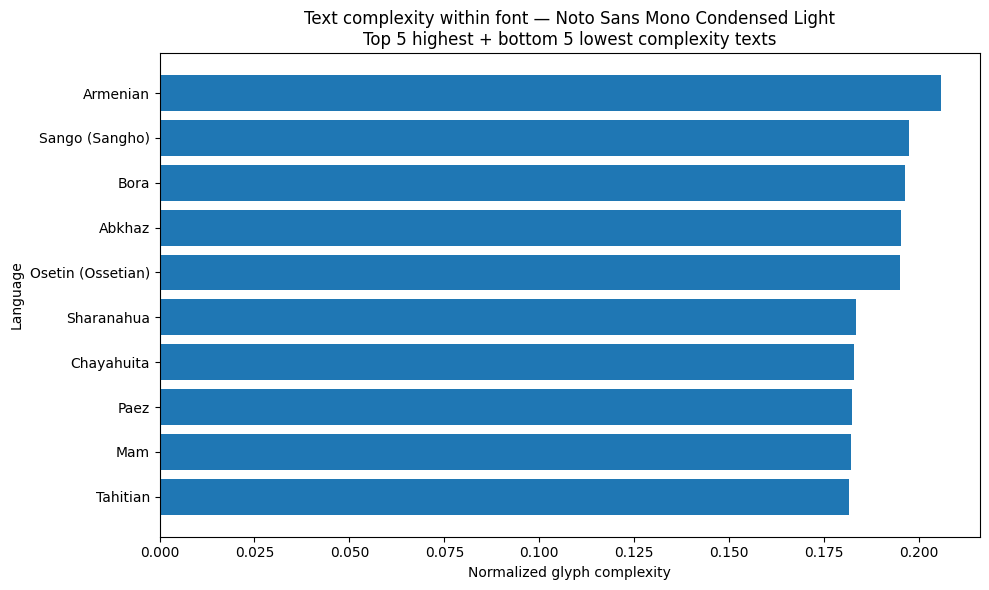

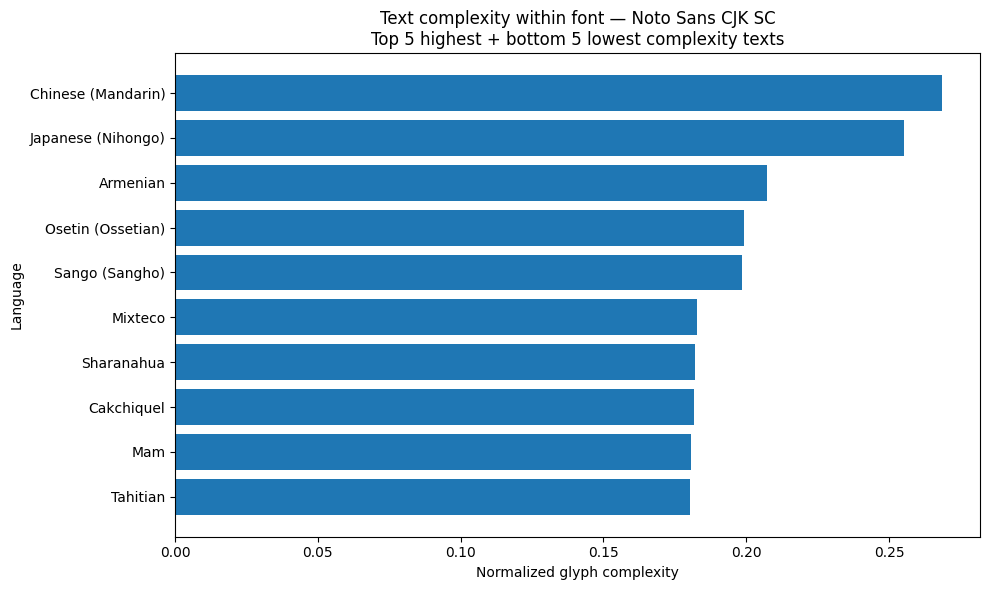

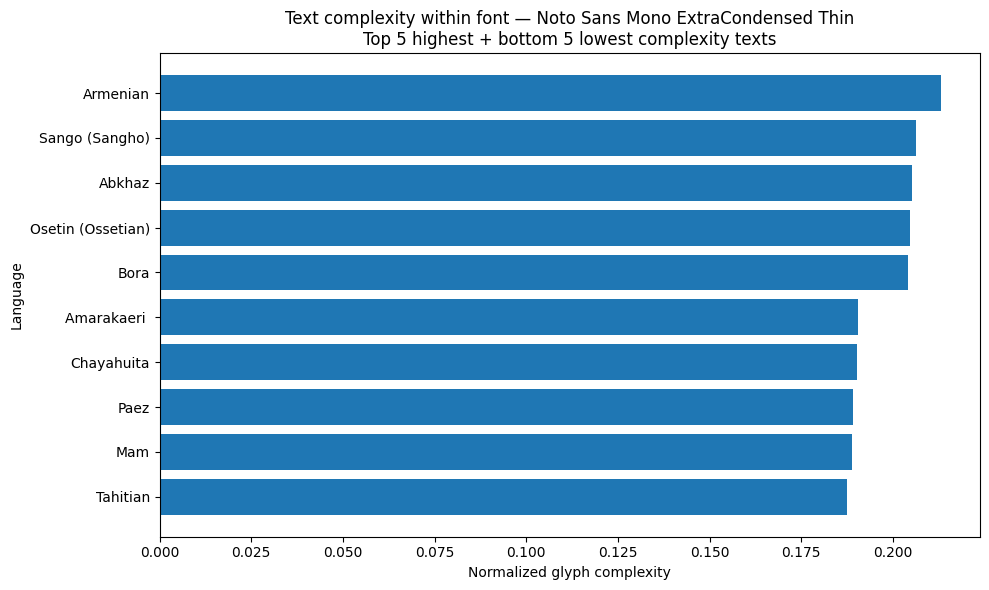

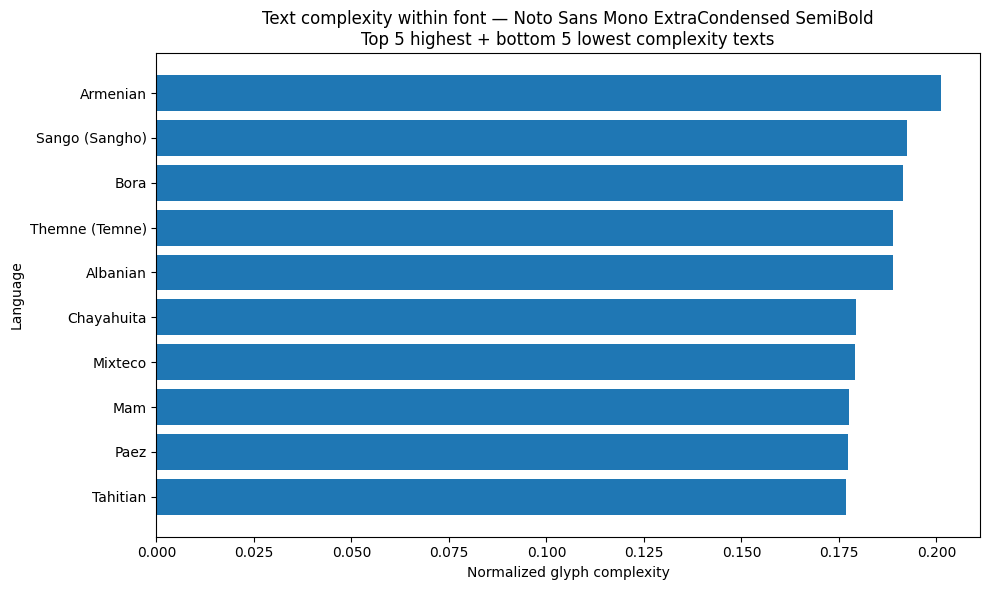

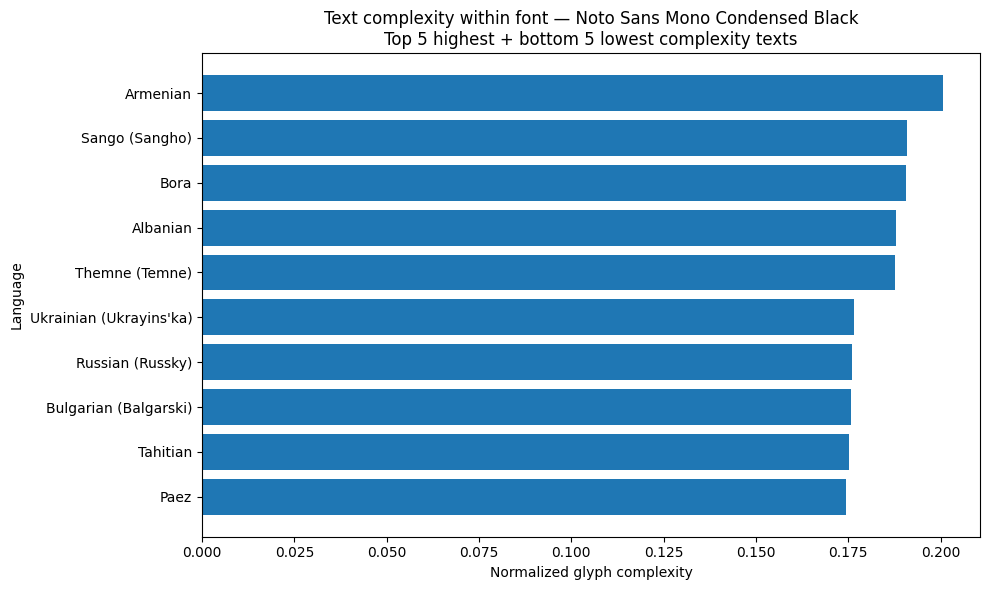

In [194]:
# Compare text complexity within each font.
#
# Each font gets its own plot.
# Only texts with complete coverage for that font are included.
#
# plot_selection:
#     "top"    = 5 highest-complexity texts
#     "bottom" = 5 lowest-complexity texts
#     "both"   = 5 highest + 5 lowest
#     "all"    = all texts

plot_selection = "both"

n = 5


for font_id in sorted(
    text_complexity["font_id"].unique()
):

    plot_data = (
        text_complexity[
            text_complexity["font_id"] == font_id
        ]
        .sort_values(
            "normalized_complexity",
            ascending=False
        )
        .copy()
    )


    if plot_data.empty:
        continue


    # Select texts

    if plot_selection == "top":

        plot_data = (
            plot_data
            .head(n)
        )


    elif plot_selection == "bottom":

        plot_data = (
            plot_data
            .tail(n)
        )


    elif plot_selection == "both":

        top = (
            plot_data
            .head(n)
        )

        bottom = (
            plot_data
            .tail(n)
        )

        plot_data = (
            pd.concat(
                [
                    top,
                    bottom
                ]
            )
            .drop_duplicates(
                subset=["language"]
            )
        )


    elif plot_selection == "all":

        pass


    else:

        raise ValueError(
            "plot_selection must be "
            "'top', 'bottom', 'both', or 'all'."
        )


    # Sort for plotting

    plot_data = (
        plot_data
        .sort_values(
            "normalized_complexity",
            ascending=True
        )
    )


    font_name = (
        plot_data["font_name"].iloc[0]
    )


    # Human-readable description for the title

    selection_label = {
        "top": f"Top {n} highest",
        "bottom": f"Bottom {n} lowest",
        "both": f"Top {n} highest + bottom {n} lowest",
        "all": "All"
    }[plot_selection]


    plt.figure(
        figsize=(
            10,
            max(
                6,
                0.3 * len(plot_data)
            )
        )
    )


    plt.barh(
        plot_data["language_name"],
        plot_data["normalized_complexity"]
    )


    plt.xlabel(
        "Normalized glyph complexity"
    )

    plt.ylabel(
        "Language"
    )

    plt.title(
        f"Text complexity within font — {font_name}\n"
        f"{selection_label} complexity texts"
    )


    plt.tight_layout()

    plt.show()

In [185]:
# Count usable fonts for each text.

fonts_per_text = (
    text_complexity
    .groupby("language")
    .agg(
        usable_fonts=(
            "font_id",
            "nunique"
        )
    )
    .sort_values(
        "usable_fonts",
        ascending=False
    )
    .reset_index()
)


print(
    "TEXTS WITH MULTIPLE USABLE FONTS"
)

display(
    fonts_per_text[
        fonts_per_text["usable_fonts"] > 1
    ]
)

TEXTS WITH MULTIPLE USABLE FONTS


,language,usable_fonts
0,abk,5
1,acu,5
2,afk,5
3,agr,5
4,aln,5
...,...,...
229,tws1,4
230,tsh,4
231,tsw,4
232,ukr,4


In [207]:
# ============================================================
# Configure Matplotlib to use Noto Sans fonts
# ============================================================
#
# This prevents missing-glyph rectangles for CJK and other
# Unicode characters.
# ============================================================

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager


# ------------------------------------------------------------
# Find Noto Sans fonts
# ------------------------------------------------------------

noto_font_paths = [
    path
    for path in font_manager.findSystemFonts()
    if "NotoSans" in path.replace("-", "")
]


print(
    f"Noto Sans font files found: "
    f"{len(noto_font_paths):,}"
)


# ------------------------------------------------------------
# Register all discovered Noto fonts with Matplotlib
# ------------------------------------------------------------

for font_path in noto_font_paths:

    try:

        font_manager.fontManager.addfont(
            font_path
        )

    except Exception:
        pass


# ------------------------------------------------------------
# Find a Unicode-capable default font
# ------------------------------------------------------------

preferred_fonts = [
    "Noto Sans CJK JP",
    "Noto Sans",
    "Noto Sans JP",
    "Noto Sans CJK",
]


available_font_names = {
    font.name
    for font in font_manager.fontManager.ttflist
}


selected_default_font = None

for font_name in preferred_fonts:

    if font_name in available_font_names:

        selected_default_font = font_name
        break


if selected_default_font is None:

    raise RuntimeError(
        "Could not find a suitable Noto Sans font."
    )


# ------------------------------------------------------------
# Set Matplotlib defaults
# ------------------------------------------------------------

matplotlib.rcParams["font.family"] = [
    selected_default_font
]

# Prevent minus signs from becoming missing glyphs
matplotlib.rcParams["axes.unicode_minus"] = False


print(
    f"Matplotlib default font: "
    f"{selected_default_font}"
)

Noto Sans font files found: 1,530
Matplotlib default font: Noto Sans CJK JP


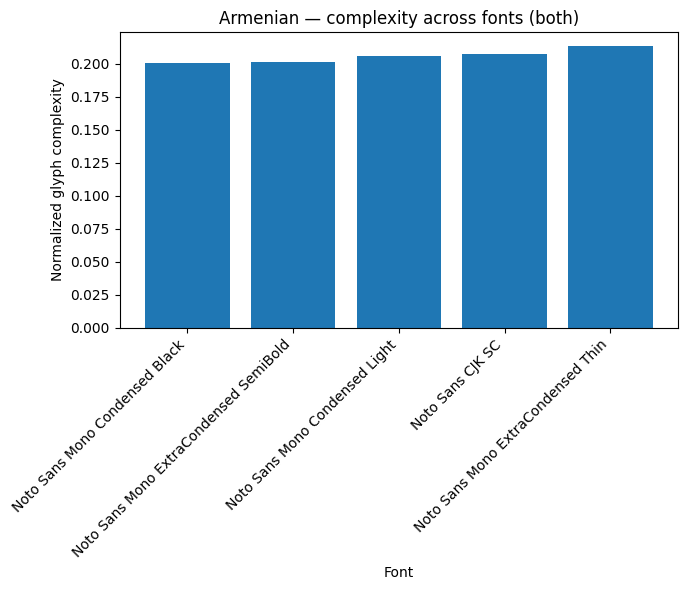

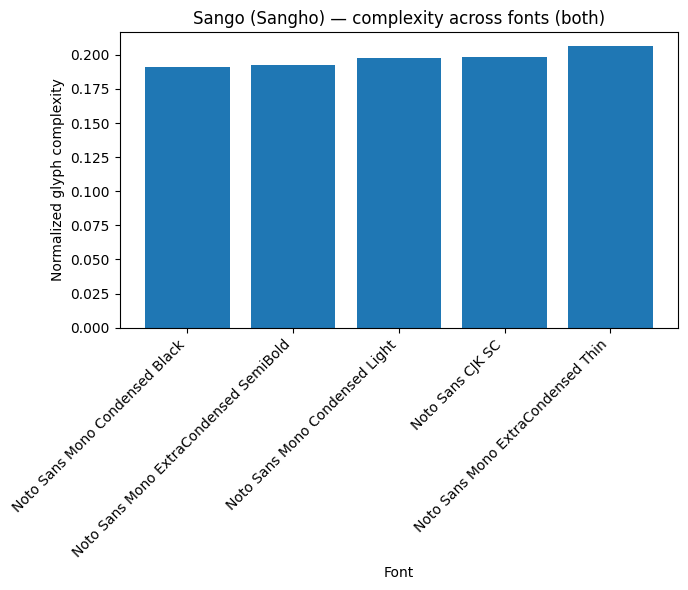

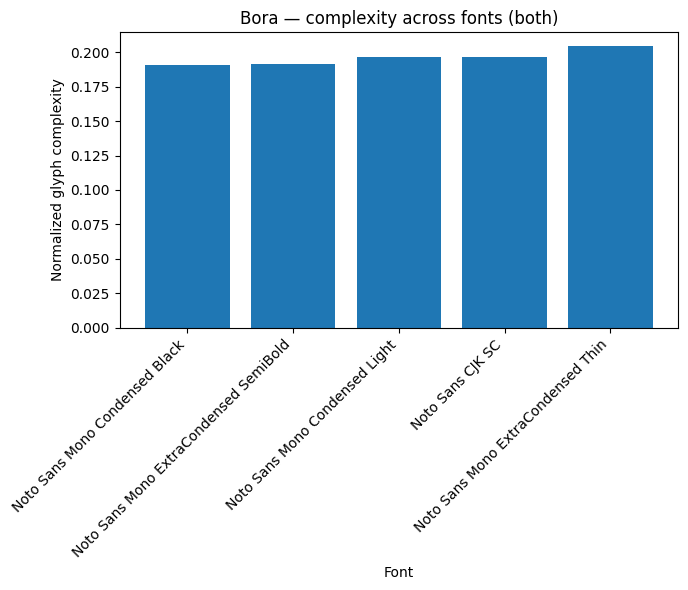

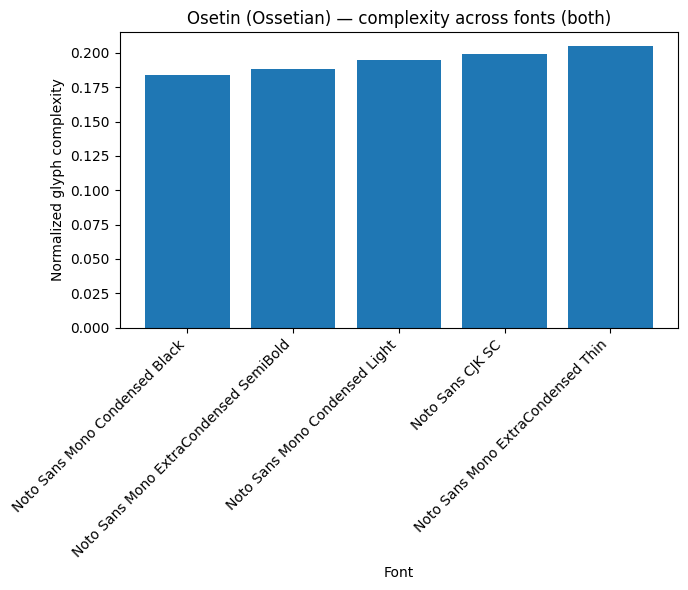

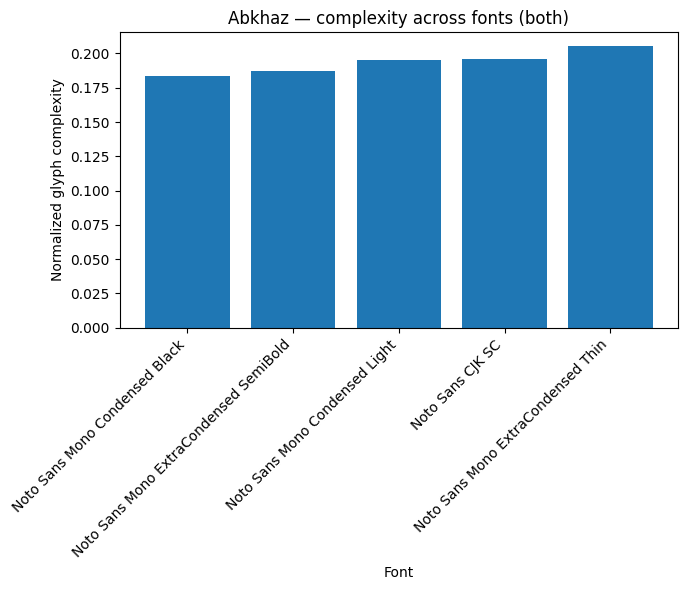

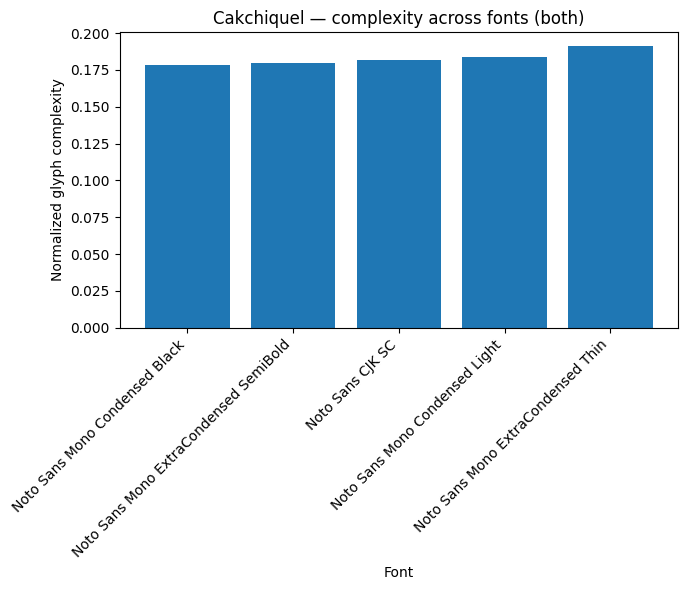

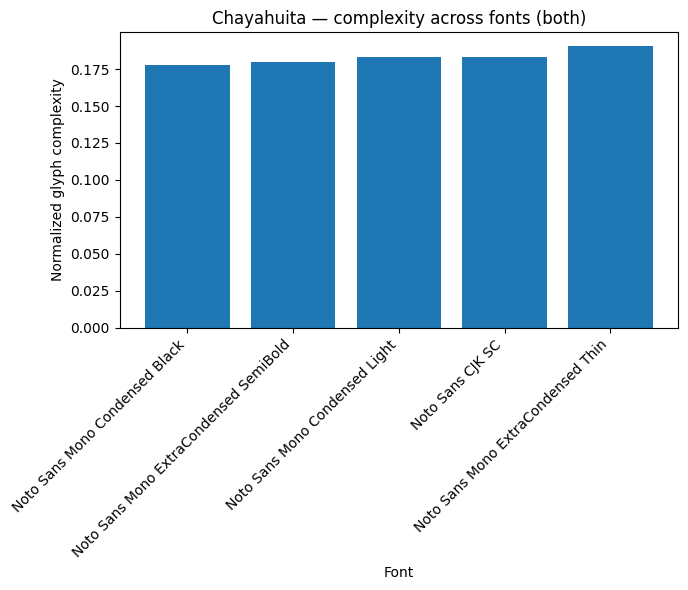

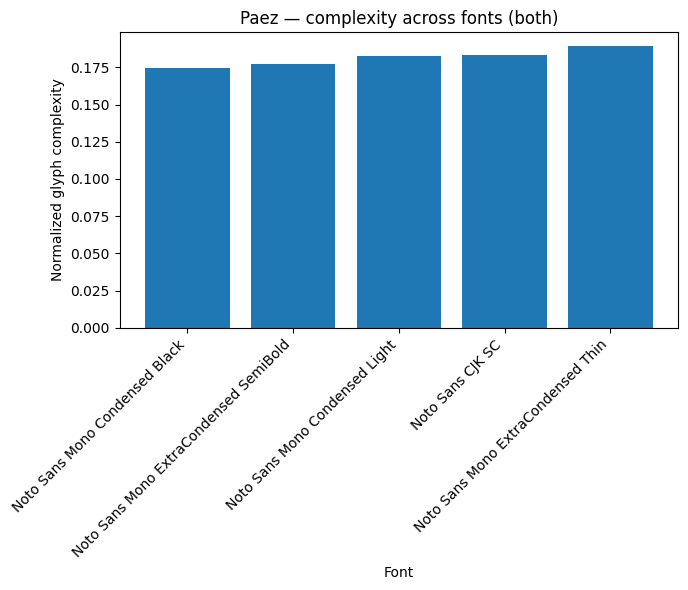

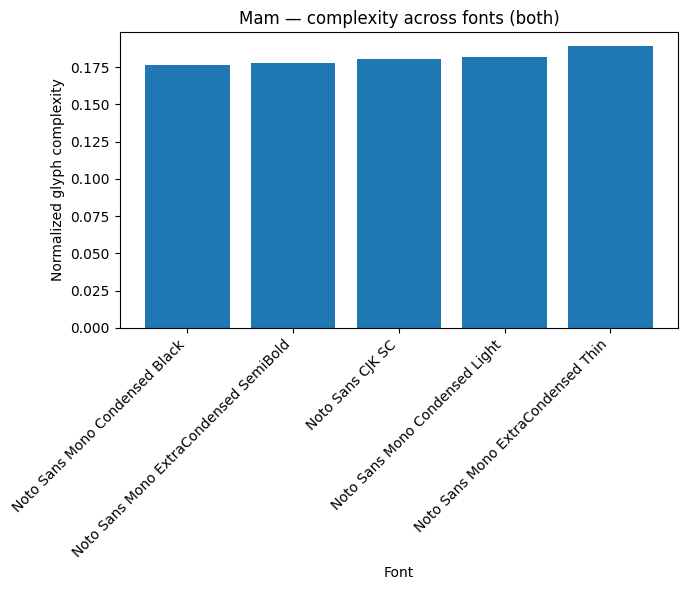

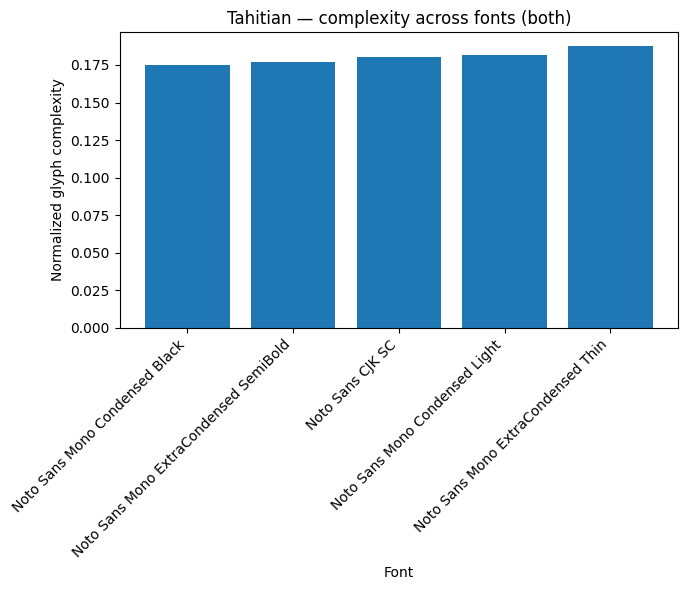

In [196]:
# Compare normalized complexity across fonts for selected texts.
#
# Texts are ranked by their normalized complexity.
# For each selected text, all usable fonts are plotted.
#
# plot_selection:
#     "top"    = 5 highest-complexity texts
#     "bottom" = 5 lowest-complexity texts
#     "both"   = 5 highest + 5 lowest
#     "all"    = all texts
#
# Only texts with at least TWO usable fonts are plotted.

plot_selection = "both"

n = 5


# ------------------------------------------------------------
# Determine which texts have at least two usable fonts
# ------------------------------------------------------------

fonts_per_text = (
    text_complexity
    .groupby("language")["font_id"]
    .nunique()
)


texts_with_multiple_fonts = (
    fonts_per_text[
        fonts_per_text >= 2
    ]
    .index
    .tolist()
)


# ------------------------------------------------------------
# Calculate one complexity value per text
# ------------------------------------------------------------
#
# This is used ONLY to rank the texts.
# The actual plots still show every usable font for the text.

text_ranking = (
    text_complexity[
        text_complexity["language"].isin(
            texts_with_multiple_fonts
        )
    ]
    .groupby(
        "language",
        as_index=False
    )["normalized_complexity"]
    .mean()
    .sort_values(
        "normalized_complexity",
        ascending=False
    )
)


# ------------------------------------------------------------
# Select texts
# ------------------------------------------------------------

if plot_selection == "top":

    selected_texts = (
        text_ranking
        .head(n)["language"]
        .tolist()
    )


elif plot_selection == "bottom":

    selected_texts = (
        text_ranking
        .tail(n)["language"]
        .tolist()
    )


elif plot_selection == "both":

    top = (
        text_ranking
        .head(n)["language"]
        .tolist()
    )

    bottom = (
        text_ranking
        .tail(n)["language"]
        .tolist()
    )

    selected_texts = list(
        dict.fromkeys(
            top + bottom
        )
    )


elif plot_selection == "all":

    selected_texts = (
        text_ranking["language"]
        .tolist()
    )


else:

    raise ValueError(
        "plot_selection must be "
        "'top', 'bottom', 'both', or 'all'."
    )


# ------------------------------------------------------------
# Plot each selected text across fonts
# ------------------------------------------------------------

for language in selected_texts:

    plot_data = (
        text_complexity[
            text_complexity["language"] == language
        ]
        .sort_values(
            "normalized_complexity",
            ascending=True
        )
        .copy()
    )


    # Safety check: only plot if at least two fonts
    if plot_data["font_id"].nunique() < 2:
        continue


    language_name = (
        plot_data["language_name"].iloc[0]
    )


    plt.figure(
        figsize=(
            max(
                7,
                1.2 * len(plot_data)
            ),
            6
        )
    )


    plt.bar(
        plot_data["font_name"],
        plot_data["normalized_complexity"]
    )


    plt.xlabel(
        "Font"
    )

    plt.ylabel(
        "Normalized glyph complexity"
    )


    plt.title(
        f"{language_name} — complexity across fonts "
        f"({plot_selection})"
    )


    plt.xticks(
        rotation=45,
        ha="right"
    )


    plt.tight_layout()

    plt.show()

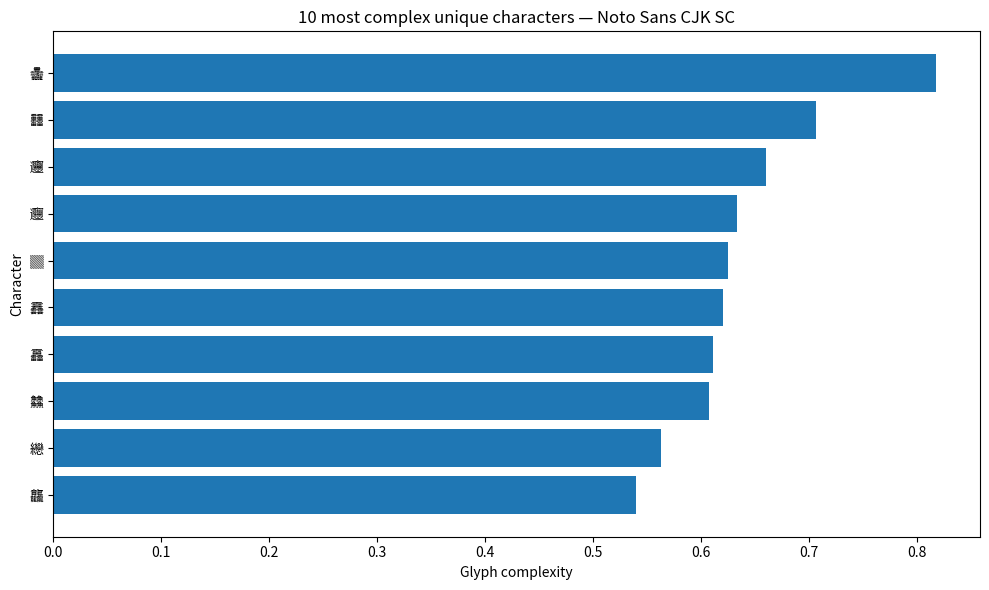

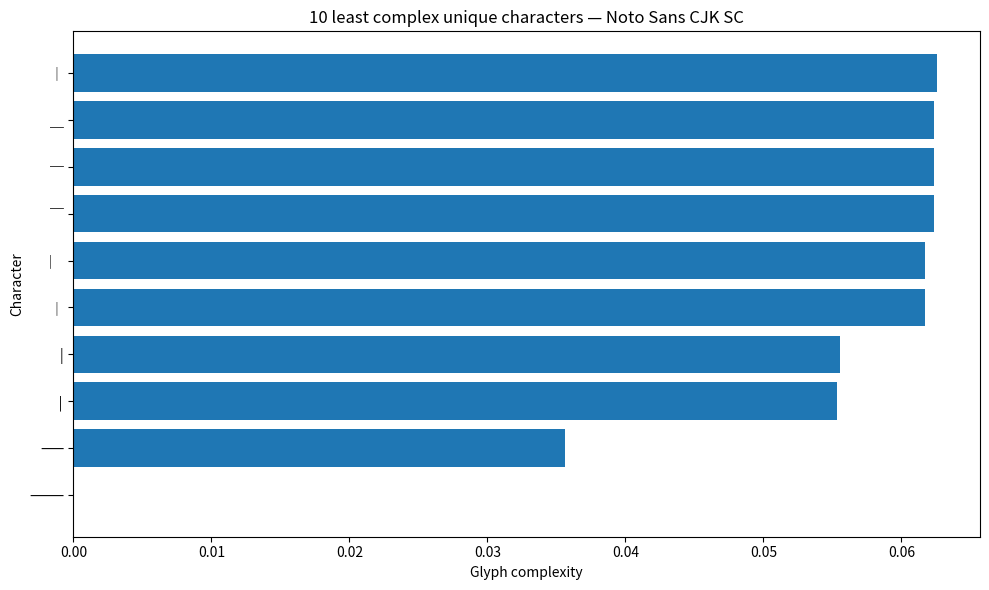

/tmp/ipykernel_1304/3766184938.py:114: UserWarning: Glyph 11790 (\N{EDITORIAL CORONIS}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/tmp/ipykernel_1304/3766184938.py:114: UserWarning: Glyph 8241 (\N{PER TEN THOUSAND SIGN}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/tmp/ipykernel_1304/3766184938.py:114: UserWarning: Glyph 42606 (\N{CYRILLIC LETTER MULTIOCULAR O}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/tmp/ipykernel_1304/3766184938.py:114: UserWarning: Glyph 65532 (\N{OBJECT REPLACEMENT CHARACTER}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11790 (\N{EDITORIAL CORONIS}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8241 (\N{PER TEN THOUSAND SIGN}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.prin

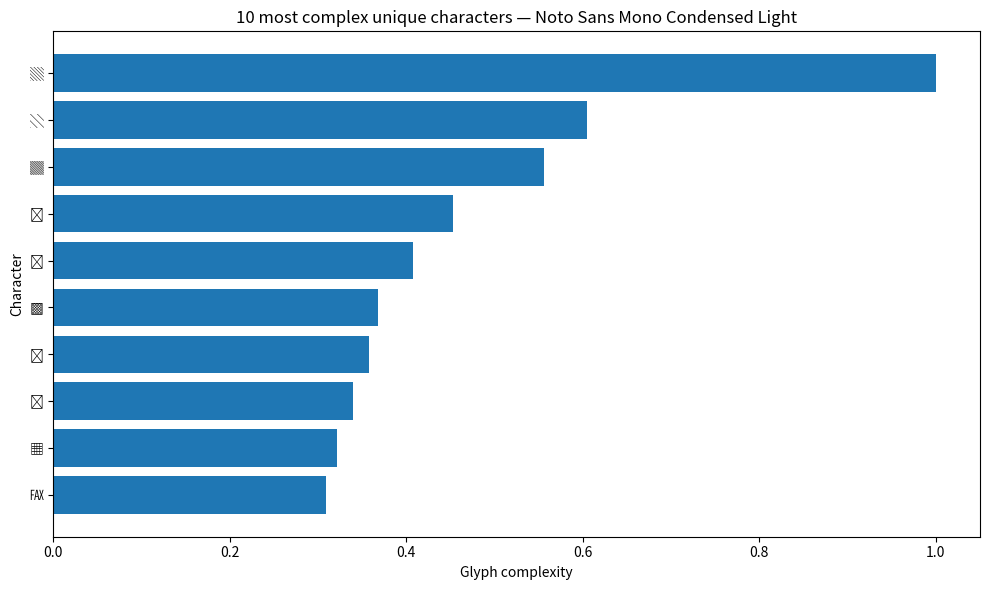

/tmp/ipykernel_1304/3766184938.py:160: UserWarning: Glyph 9130 (\N{CURLY BRACKET EXTENSION}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/tmp/ipykernel_1304/3766184938.py:160: UserWarning: Glyph 9119 (\N{RIGHT PARENTHESIS EXTENSION}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/tmp/ipykernel_1304/3766184938.py:160: UserWarning: Glyph 9116 (\N{LEFT PARENTHESIS EXTENSION}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/tmp/ipykernel_1304/3766184938.py:160: UserWarning: Glyph 9125 (\N{RIGHT SQUARE BRACKET EXTENSION}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/tmp/ipykernel_1304/3766184938.py:160: UserWarning: Glyph 9122 (\N{LEFT SQUARE BRACKET EXTENSION}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9130 (\N{CURLY BRACKET EXTENSION}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

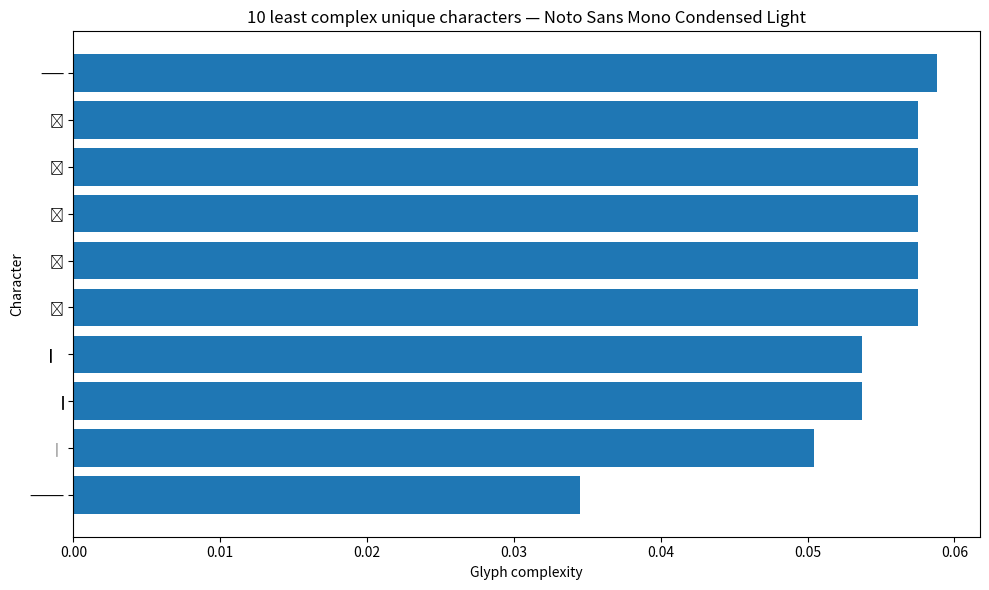

In [208]:
# Plot the 10 most and least complex UNIQUE characters
# for two selected fonts.
#
# Each character appears only once per font.
#
# Change these to the two fonts you want to examine.

font_1 = analysis_fonts[0]
font_2 = analysis_fonts[1]


for font_id in [font_1, font_2]:

    font_data = (
        glyph_complexity_database[
            glyph_complexity_database["font_id"] == font_id
        ]
        .copy()
    )


    if font_data.empty:
        print(
            f"No data found for font_id: {font_id}"
        )
        continue


    font_name = (
        font_data["font_name"]
        .iloc[0]
    )


    # --------------------------------------------------------
    # Create character from codepoint
    # --------------------------------------------------------

    font_data["character"] = (
        font_data["codepoint"]
        .apply(chr)
    )


    # --------------------------------------------------------
    # Collapse to ONE row per unique character
    # --------------------------------------------------------
    #
    # One character is identified by:
    #     font_id + codepoint
    #
    # Complexity should be identical for the same
    # font + codepoint, so keep the first value.

    unique_chars = (
        font_data[
            [
                "font_id",
                "codepoint",
                "character",
                "complexity"
            ]
        ]
        .drop_duplicates(
            subset=[
                "font_id",
                "codepoint"
            ]
        )
    )


    # --------------------------------------------------------
    # 10 MOST complex
    # --------------------------------------------------------

    most_complex = (
        unique_chars
        .sort_values(
            "complexity",
            ascending=False
        )
        .head(10)
        .sort_values(
            "complexity",
            ascending=True
        )
    )


    plt.figure(
        figsize=(10, 6)
    )


    plt.barh(
        most_complex["character"],
        most_complex["complexity"]
    )


    plt.xlabel(
        "Glyph complexity"
    )

    plt.ylabel(
        "Character"
    )

    plt.title(
        f"10 most complex unique characters — {font_name}"
    )

    plt.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # 10 LEAST complex
    # --------------------------------------------------------

    least_complex = (
        unique_chars
        .sort_values(
            "complexity",
            ascending=True
        )
        .head(10)
        .sort_values(
            "complexity",
            ascending=True
        )
    )


    plt.figure(
        figsize=(10, 6)
    )


    plt.barh(
        least_complex["character"],
        least_complex["complexity"]
    )


    plt.xlabel(
        "Glyph complexity"
    )

    plt.ylabel(
        "Character"
    )

    plt.title(
        f"10 least complex unique characters — {font_name}"
    )

    plt.tight_layout()

    plt.show()

In [209]:
# Inspect the characters being selected for the plots

for font_id in [font_1, font_2]:

    font_data = (
        glyph_complexity_database[
            glyph_complexity_database["font_id"] == font_id
        ]
        .copy()
    )

    font_data["character"] = (
        font_data["codepoint"].apply(chr)
    )

    unique_chars = (
        font_data[
            [
                "font_id",
                "codepoint",
                "character",
                "complexity"
            ]
        ]
        .drop_duplicates(
            subset=[
                "font_id",
                "codepoint"
            ]
        )
    )

    print(
        "\nFONT:",
        font_data["font_name"].iloc[0]
    )

    print("\nMost complex:")
    print(
        unique_chars
        .sort_values(
            "complexity",
            ascending=False
        )
        .head(10)[
            [
                "codepoint",
                "character",
                "complexity"
            ]
        ]
        .to_string(index=False)
    )

    print("\nLeast complex:")
    print(
        unique_chars
        .sort_values(
            "complexity",
            ascending=True
        )
        .head(10)[
            [
                "codepoint",
                "character",
                "complexity"
            ]
        ]
        .to_string(index=False)
    )


FONT: Noto Sans CJK SC

Most complex:
 codepoint character  complexity
    200812         𱁬    0.817207
     19003         䨻    0.706270
    200414         𰻞    0.660111
    200413         𰻝    0.633263
      9619         ▓    0.625221
     19002         䨺    0.620446
     38736         靐    0.611149
     19612         䲜    0.606958
     32414         纞    0.562985
     40856         龘    0.539180

Least complex:
 codepoint character  complexity
     11835         ⸻    0.000000
     11834         ⸺    0.035634
     65512         ￨    0.055307
       124         |    0.055533
     65372         ｜    0.061741
     65075         ︳    0.061741
     65507         ￣    0.062346
      9472         ─    0.062346
     65343         ＿    0.062346
      9474         │    0.062568

FONT: Noto Sans Mono Condensed Light

Most complex:
 codepoint character  complexity
      9618         ▒    1.000000
      9617         ░    0.605318
      9619         ▓    0.556158
     65532         ￼    0.452467
 

In [210]:
# ============================================================
# LIST TEXT INDICES
#
# Use these indices in:
#     text_indices = [0, 3, 7]
# ============================================================

languages = list(
    character_inventories.keys()
)

print("AVAILABLE TEXTS")
print("=" * 80)

for index, language in enumerate(languages):

    print(
        f"{index:3d}  "
        f"{language:10s}  "
        f"{language_names.get(language, 'UNKNOWN')}"
    )
    # ============================================================
# LIST FONT INDICES
#
# Use these indices in:
#     font_index = 0
# ============================================================

print("AVAILABLE ANALYSIS FONTS")
print("=" * 100)

for index, font_id in enumerate(analysis_fonts):

    font_rows = (
        font_table[
            font_table["font_id"] == font_id
        ]
    )

    if not font_rows.empty:

        font_name = (
            font_rows["font_name"]
            .iloc[0]
        )

        family_name = (
            font_rows["family_name"]
            .iloc[0]
        )

    else:

        font_name = "UNKNOWN"
        family_name = "UNKNOWN"


    print(
        f"{index:3d}  "
        f"font_id={font_id:<6}  "
        f"{font_name}"
    )

AVAILABLE TEXTS
  0  abk         Abkhaz
  1  acu         Achuar-Shiwiar
  2  afk         Afrikaans
  3  agr         Aguaruna
  4  aln         Albanian
  5  amc         Amahuaca
  6  amr         Amarakaeri 
  7  arl         Arabela
  8  arm         Armenian
  9  aru         Mapudungun (Mapuzgun)
 10  ass         Asante 
 11  atj         Achehnese
 12  aub         Asturian (Bable)
 13  auv1        Occitan Auvergnat
 14  aym         Aymara
 15  bci         Baoulé/Baule
 16  bcy         Bichelamar
 17  bem         Bemba
 18  bkl         Bikol/Bicolano
 19  blg         Bulgarian (Balgarski)
 20  blu         Hmong (Miao), Sichuan-Guizhou-Yunnan
 21  boa         Bora
 22  bpr         Bugisnese
 23  bra         Bambara
 24  brt         Breton
 25  bsq         Basque (Euskara)
 26  btb         Béti
 27  bzc         Balinese
 28  cab         Garifuna
 29  cak1        Cakchiquel
 30  cbr         Cashibo-Cacataibo
 31  cbs         Cashinahua
 32  cbt         Chayahuita
 33  cbu         Candoshi-Sh

Font: Noto Sans CJK SC
Font ID: 2142

Selected texts:
  index 37: chn — Chinese (Mandarin)
  index 186: rus — Russian (Russky)
  index 197: spn — Español (Spanish)
  index 99: jpn — Japanese (Nihongo)
  index 56: eng — English


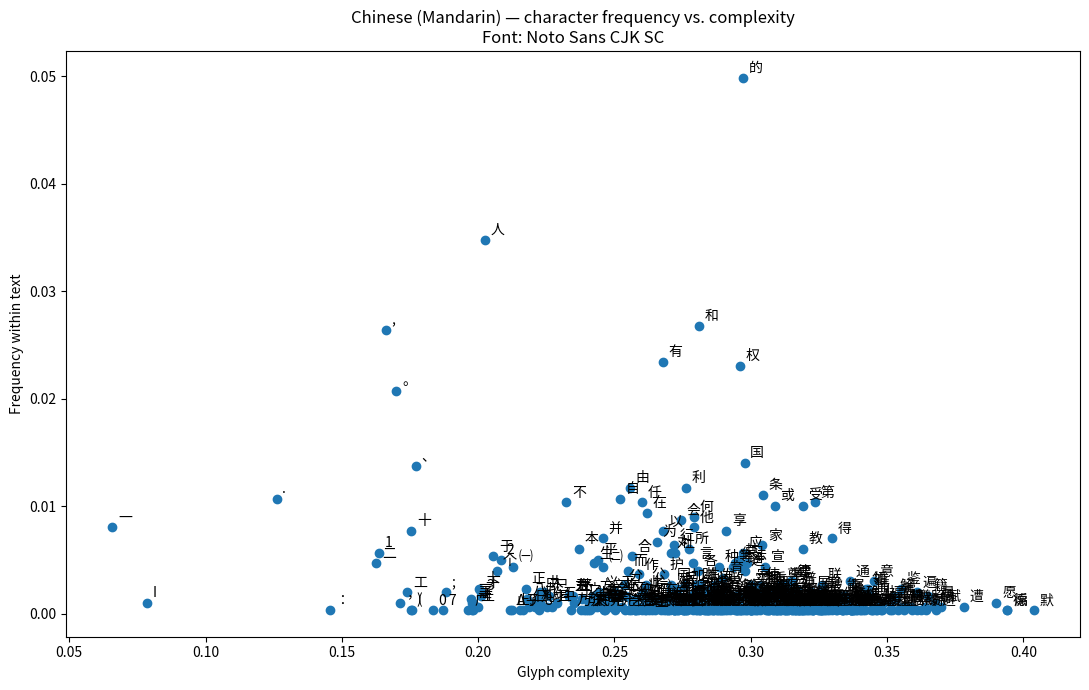

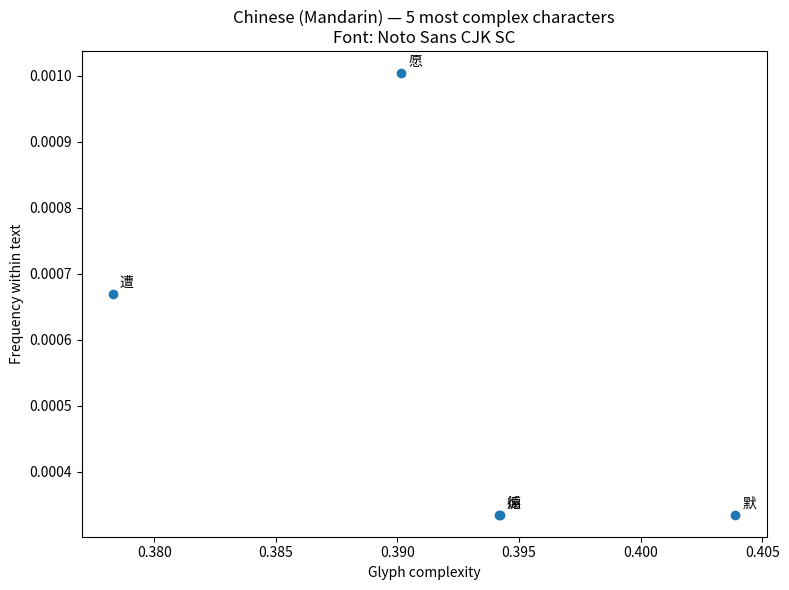

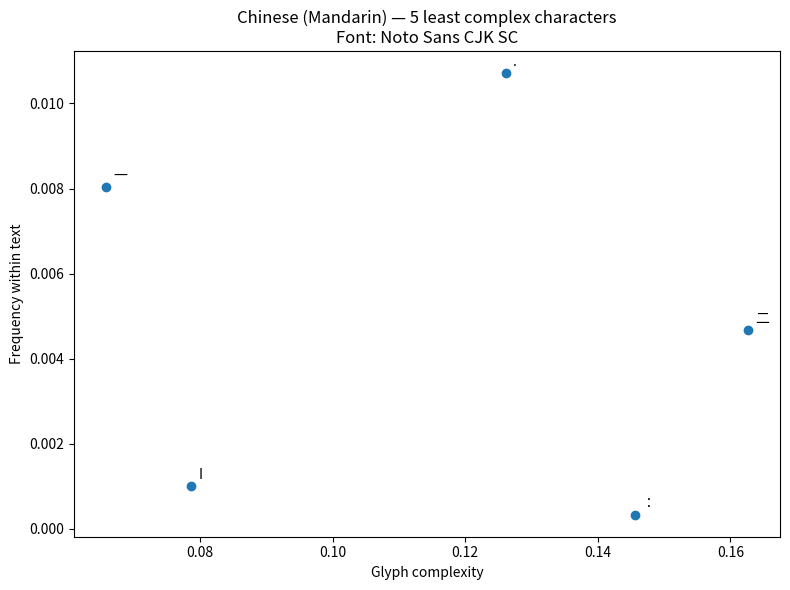

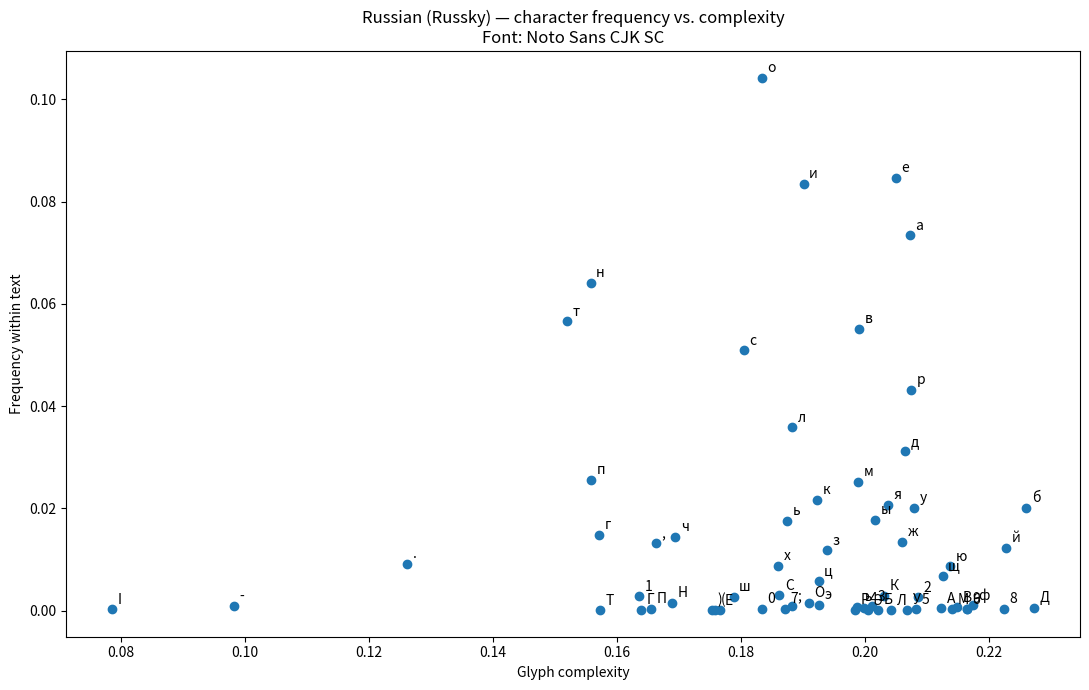

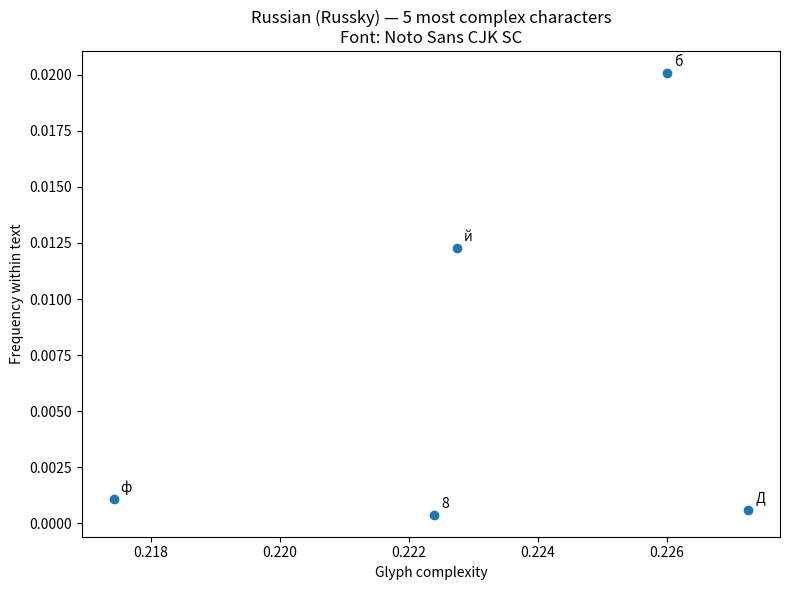

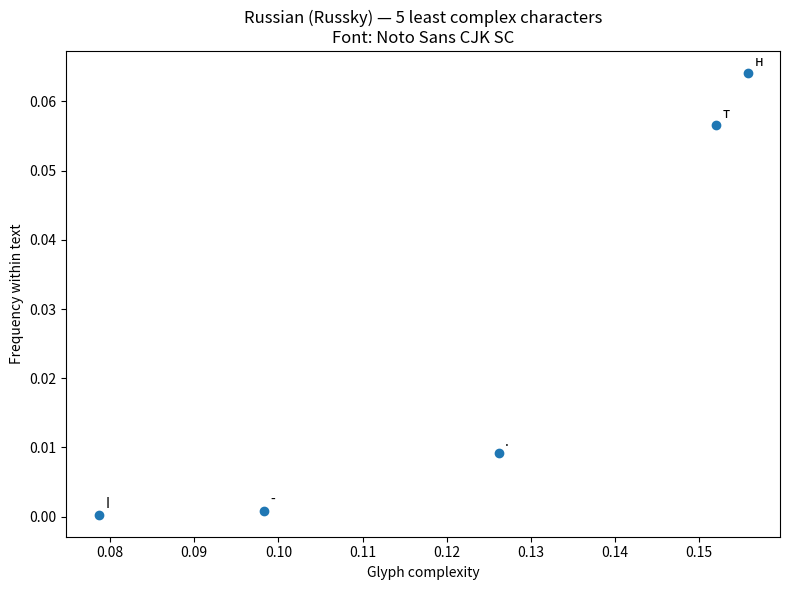

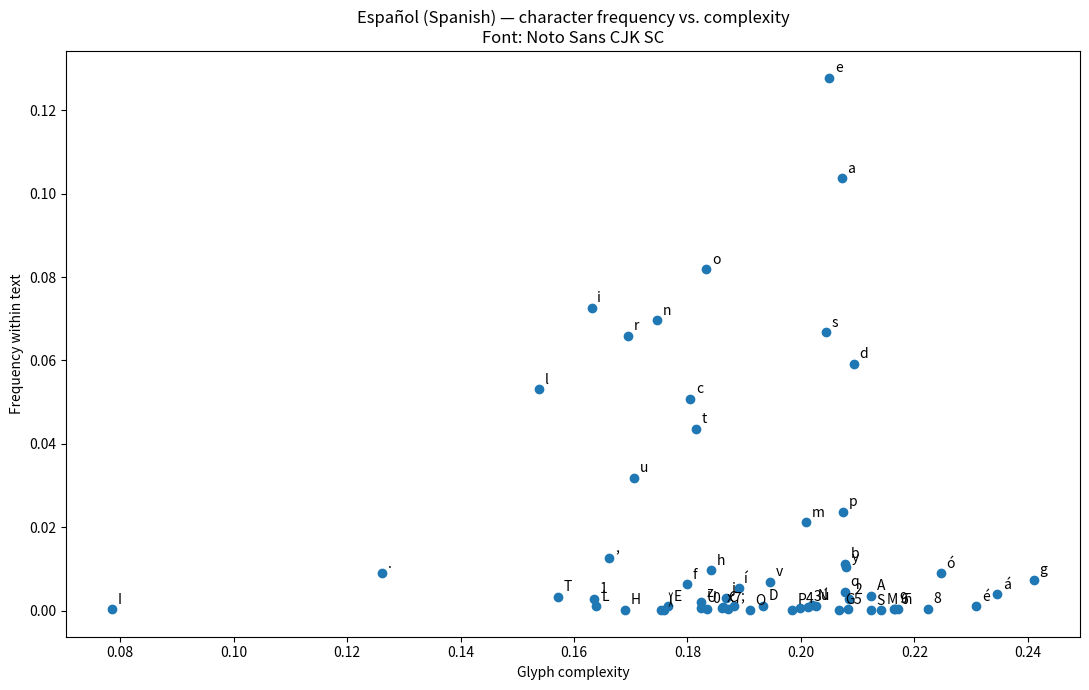

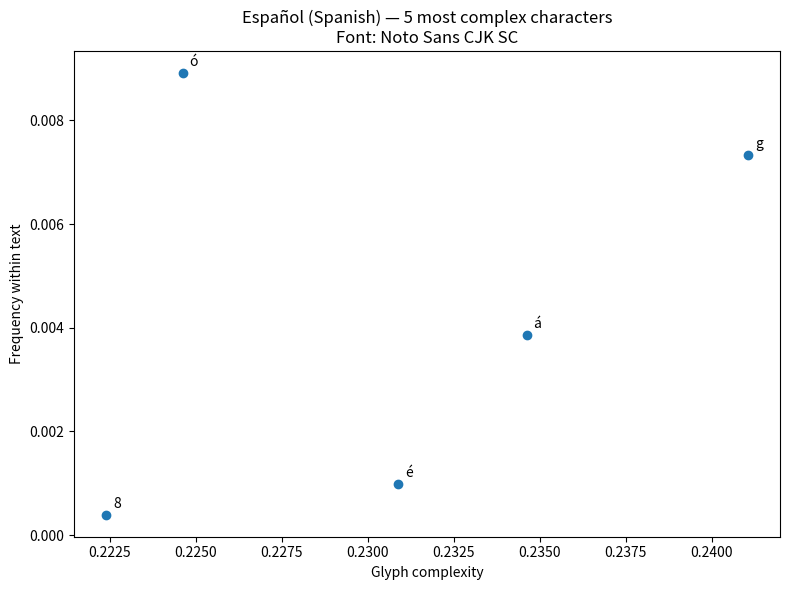

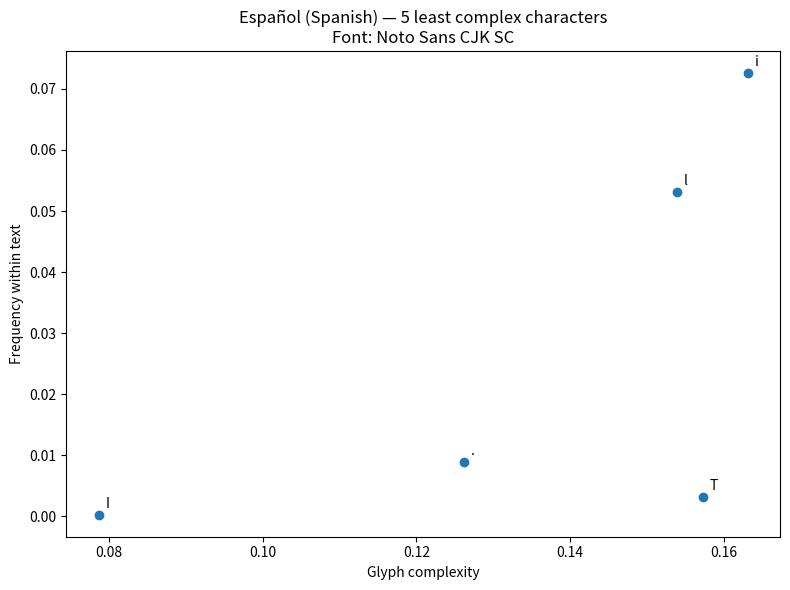

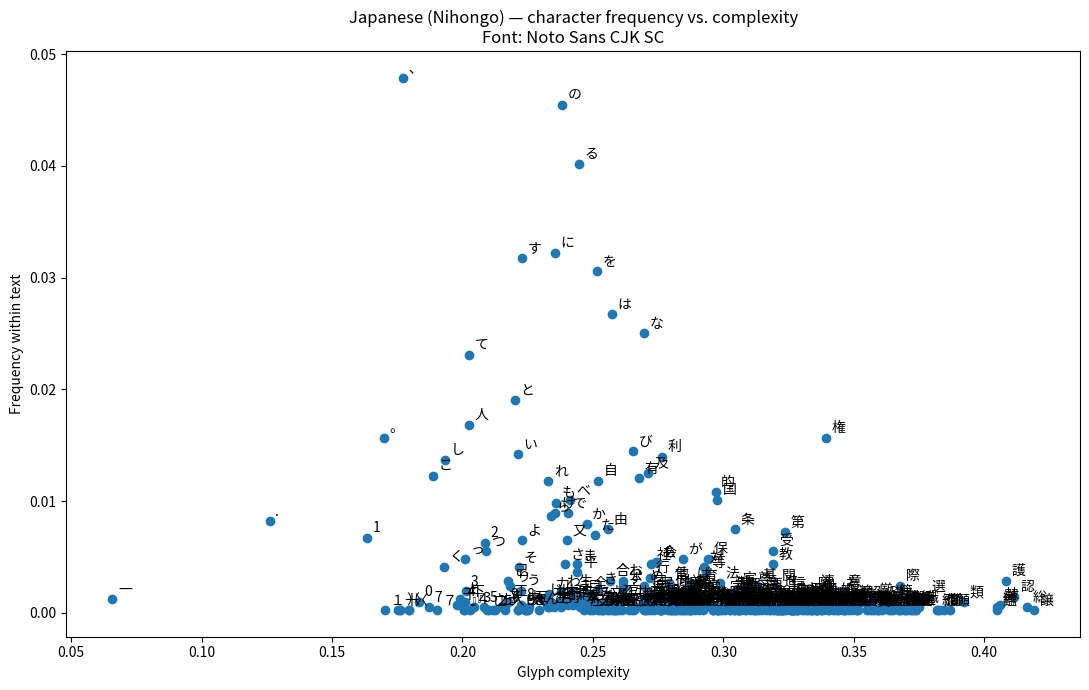

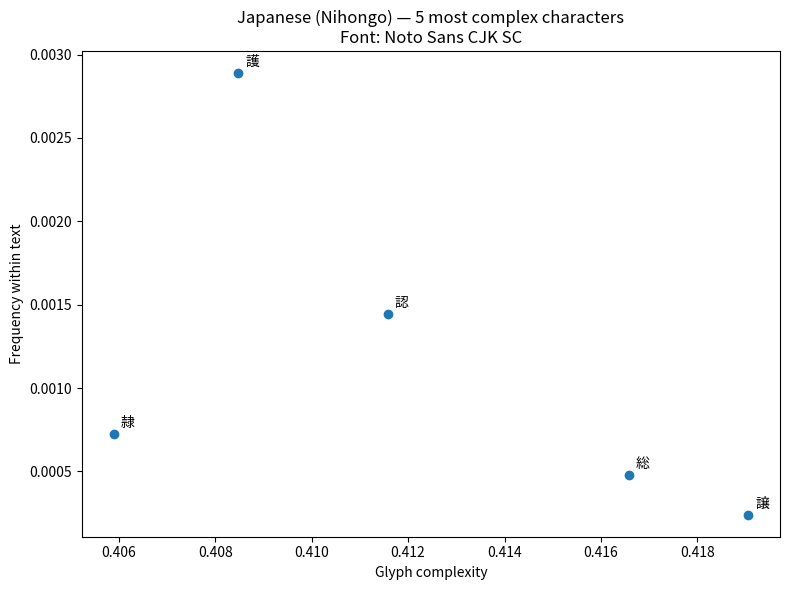

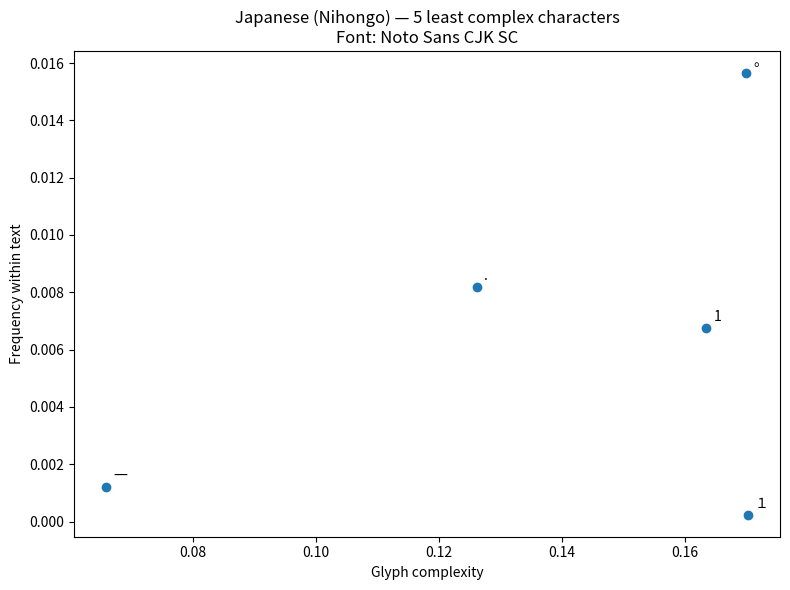

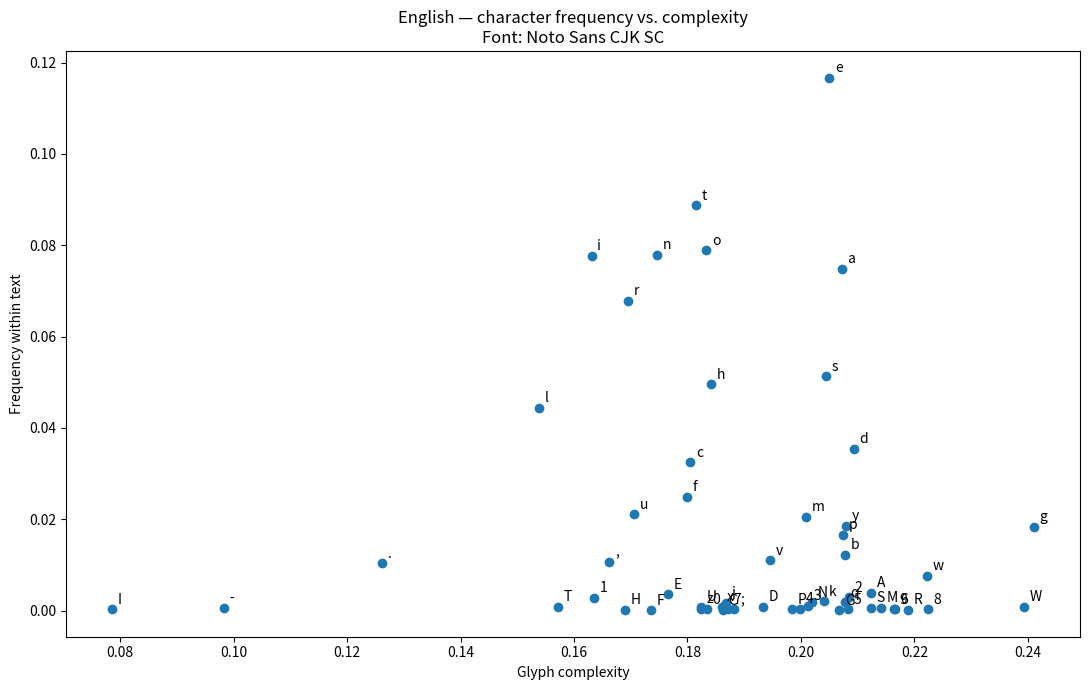

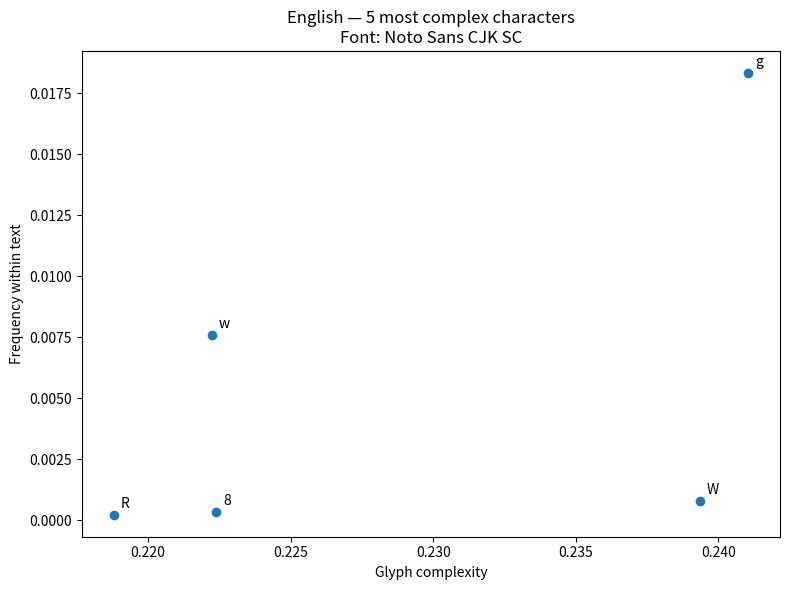

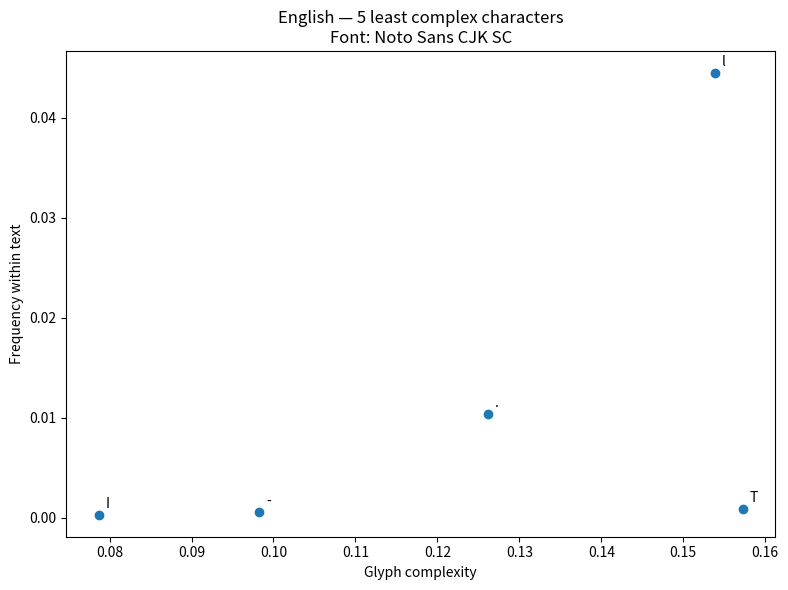

In [212]:
# ============================================================
# Character frequency vs. glyph complexity
#
# Frequency = how often the character occurs in THIS TEXT
# Complexity = glyph complexity in the SELECTED FONT
#
# text_indices:
#     Which texts to analyze by their position in the
#     current character_inventories dictionary.
#
# font_index:
#     Which font from analysis_fonts to use.
#
# Produces 3 plots for each text:
#     1. Whole text
#     2. 5 most complex characters
#     3. 5 least complex characters
#
# Whitespace is excluded.
# ============================================================


# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

text_indices = [37, 186, 197, 99, 56]

font_index = 0


# ------------------------------------------------------------
# Select font
# ------------------------------------------------------------

font_id = analysis_fonts[font_index]


font_name = (
    glyph_complexity_database[
        glyph_complexity_database["font_id"] == font_id
    ]["font_name"]
    .iloc[0]
)


# ------------------------------------------------------------
# Get texts in their current order
# ------------------------------------------------------------

languages = list(
    character_inventories.keys()
)


selected_languages = [
    languages[i]
    for i in text_indices
    if 0 <= i < len(languages)
]


print(
    f"Font: {font_name}"
)

print(
    f"Font ID: {font_id}"
)

print()

print(
    "Selected texts:"
)

for i, language in zip(
    text_indices,
    selected_languages
):

    print(
        f"  index {i}: "
        f"{language} — "
        f"{language_names.get(language, 'UNKNOWN')}"
    )


# ------------------------------------------------------------
# Analyze each text
# ------------------------------------------------------------

for language in selected_languages:

    language_name = language_names.get(
        language,
        "UNKNOWN"
    )


    inventory = (
        character_inventories[
            language
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Remove whitespace
    # --------------------------------------------------------

    plot_data = inventory[
        ~inventory["is_whitespace"]
    ].copy()


    if plot_data.empty:

        print(
            f"\nSkipping {language_name}: "
            f"no non-whitespace characters."
        )

        continue


    # --------------------------------------------------------
    # Get glyph complexity for selected font
    # --------------------------------------------------------

    plot_data["complexity"] = (
        plot_data["codepoint"]
        .apply(
            lambda cp:
                glyph_lookup.loc[
                    (font_id, cp),
                    "complexity"
                ]
            if (font_id, cp) in glyph_lookup.index
            else np.nan
        )
    )


    # Remove characters without a complexity measurement
    #
    # Normally this should produce zero removals because
    # selected_coverage_table only contains complete text/font pairs.

    missing_complexity = (
        plot_data["complexity"].isna()
    )


    if missing_complexity.any():

        print(
            f"\nWARNING: "
            f"{missing_complexity.sum():,} "
            f"characters missing complexity for "
            f"{language_name} / {font_name}"
        )


        plot_data = plot_data[
            ~missing_complexity
        ].copy()


    if plot_data.empty:

        print(
            f"\nSkipping {language_name}: "
            f"no characters with complexity data."
        )

        continue


    # --------------------------------------------------------
    # Normalize frequency
    #
    # Frequency is calculated WITHIN THIS TEXT.
    #
    # Denominator = all non-whitespace characters
    # in this text.
    # --------------------------------------------------------

    total_nonwhitespace = (
        plot_data["count"].sum()
    )


    plot_data["frequency"] = (
        plot_data["count"]
        / total_nonwhitespace
    )


    # --------------------------------------------------------
    # Sort by complexity
    # --------------------------------------------------------

    plot_data = (
        plot_data
        .sort_values(
            "complexity"
        )
        .reset_index(drop=True)
    )


       # ========================================================
    # 1. WHOLE TEXT
    # ========================================================

    plt.figure(
        figsize=(11, 7)
    )

    plt.scatter(
        plot_data["complexity"],
        plot_data["frequency"]
    )

    # Label every character

    for _, row in plot_data.iterrows():

        plt.annotate(
            row["character"],
            (
                row["complexity"],
                row["frequency"]
            ),
            xytext=(4, 4),
            textcoords="offset points"
        )

    plt.xlabel(
        "Glyph complexity"
    )

    plt.ylabel(
        "Frequency within text"
    )

    plt.title(
        f"{language_name} — character frequency vs. complexity\n"
        f"Font: {font_name}"
    )

    plt.tight_layout()

    plt.show()


    # ========================================================
    # 2. FIVE MOST COMPLEX CHARACTERS
    # ========================================================

    top_5 = (
        plot_data
        .nlargest(
            5,
            "complexity"
        )
        .sort_values(
            "complexity"
        )
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.scatter(
        top_5["complexity"],
        top_5["frequency"]
    )

    # Label each character

    for _, row in top_5.iterrows():

        plt.annotate(
            row["character"],
            (
                row["complexity"],
                row["frequency"]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

    plt.xlabel(
        "Glyph complexity"
    )

    plt.ylabel(
        "Frequency within text"
    )

    plt.title(
        f"{language_name} — 5 most complex characters\n"
        f"Font: {font_name}"
    )

    plt.tight_layout()

    plt.show()


    # ========================================================
    # 3. FIVE LEAST COMPLEX CHARACTERS
    # ========================================================

    bottom_5 = (
        plot_data
        .nsmallest(
            5,
            "complexity"
        )
        .sort_values(
            "complexity"
        )
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.scatter(
        bottom_5["complexity"],
        bottom_5["frequency"]
    )

    # Label each character

    for _, row in bottom_5.iterrows():

        plt.annotate(
            row["character"],
            (
                row["complexity"],
                row["frequency"]
            ),
            xytext=(5, 5),
            textcoords="offset points"
        )

    plt.xlabel(
        "Glyph complexity"
    )

    plt.ylabel(
        "Frequency within text"
    )

    plt.title(
        f"{language_name} — 5 least complex characters\n"
        f"Font: {font_name}"
    )

    plt.tight_layout()

    plt.show()

TEXT LENGTH SUMMARY


,group,language,language_name,total_characters,unique_characters,whitespace
0,Top 5 longest,cpu,Ashéninca,26874,62,2444
1,Top 5 longest,shp,Shipibo-Conibo,20859,68,2604
2,Top 5 longest,ame,Amuesha-Yanesha,20549,71,2595
3,Top 5 longest,mcf,Matsés,20233,57,2509
4,Top 5 longest,nhn,Nahuatl,18534,59,2446
5,Bottom 5 shortest,jpn,Japanese (Nihongo),4391,508,236
6,Bottom 5 shortest,ako,Wama,4790,62,1028
7,Bottom 5 shortest,kkn,Hankuko (Korean),4873,318,1278
8,Bottom 5 shortest,cpp,Campa pajonalino,5029,61,685
9,Bottom 5 shortest,cbs,Cashinahua,5029,61,685


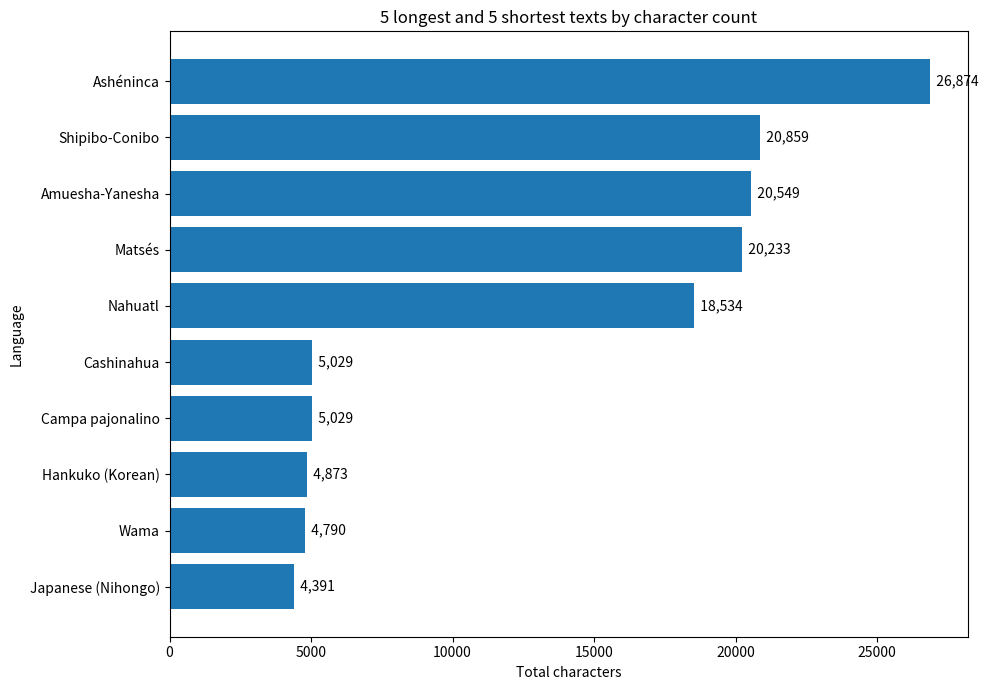

In [213]:
# ============================================================
# Texts with the most and fewest characters
#
# Character count includes whitespace.
# ============================================================

n = 5


# ------------------------------------------------------------
# Select longest and shortest texts
# ------------------------------------------------------------

longest_texts = (
    inventory_summary
    .nlargest(
        n,
        "total_characters"
    )
    .copy()
)


shortest_texts = (
    inventory_summary
    .nsmallest(
        n,
        "total_characters"
    )
    .copy()
)


# ------------------------------------------------------------
# Create combined table
# ------------------------------------------------------------

length_table = pd.concat(
    [
        longest_texts.assign(
            group=f"Top {n} longest"
        ),
        shortest_texts.assign(
            group=f"Bottom {n} shortest"
        )
    ]
)[
    [
        "group",
        "language",
        "language_name",
        "total_characters",
        "unique_characters",
        "whitespace"
    ]
].reset_index(drop=True)


print("TEXT LENGTH SUMMARY")

display(
    length_table
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plot_data = (
    length_table
    .sort_values(
        "total_characters",
        ascending=True
    )
    .copy()
)


plt.figure(
    figsize=(
        10,
        7
    )
)


plt.barh(
    plot_data["language_name"],
    plot_data["total_characters"]
)


plt.xlabel(
    "Total characters"
)

plt.ylabel(
    "Language"
)

plt.title(
    f"5 longest and 5 shortest texts by character count"
)


# Add exact character counts to bars

for i, (_, row) in enumerate(
    plot_data.iterrows()
):

    plt.text(
        row["total_characters"],
        i,
        f"  {row['total_characters']:,}",
        va="center"
    )


plt.tight_layout()

plt.show()

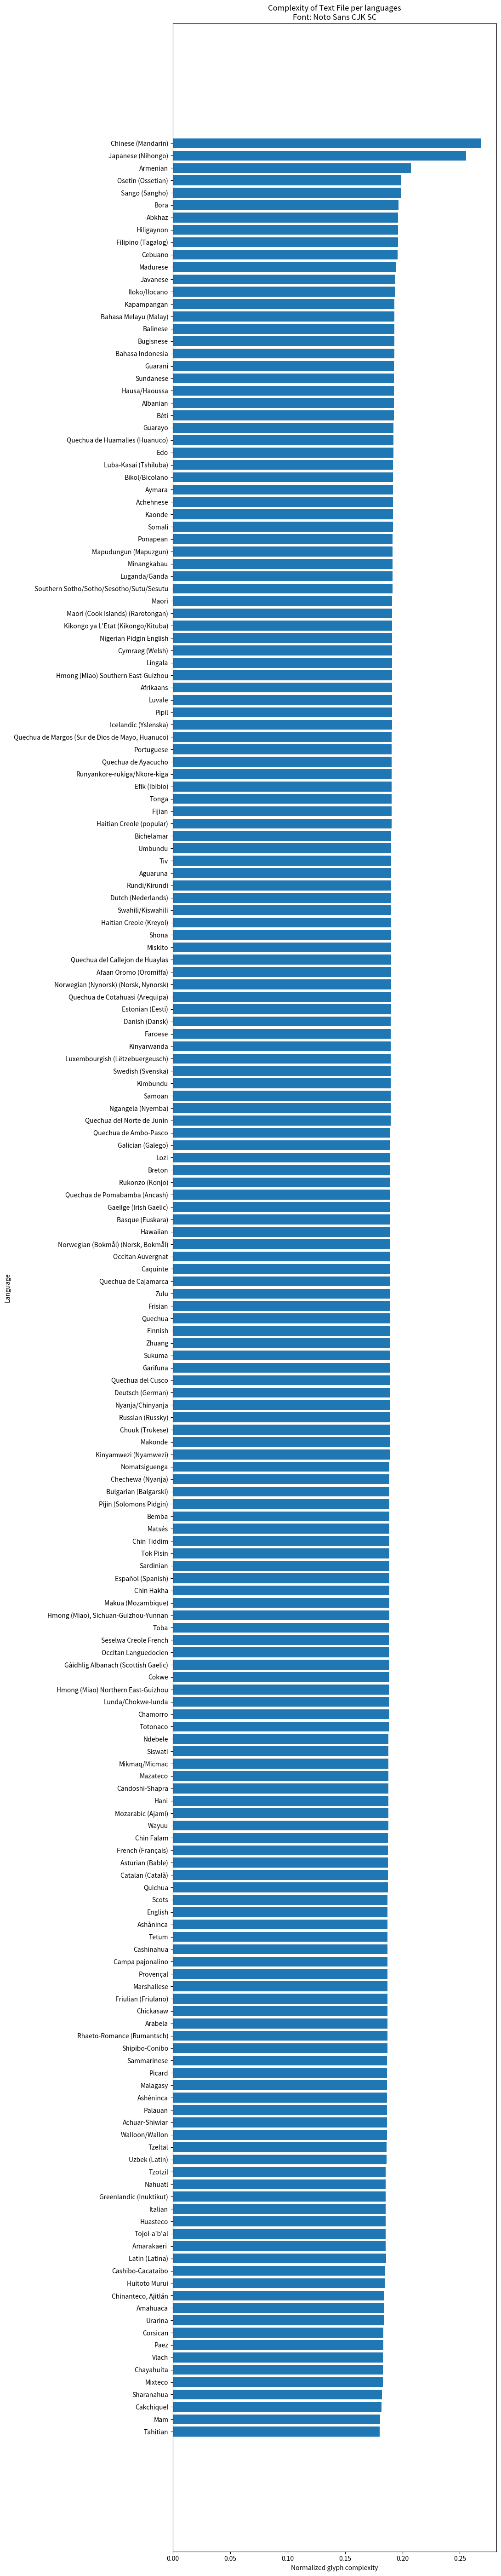

In [215]:
# ============================================================
# Compare total text complexity across all languages:
# Sum complexity per character, divide by number of nonwhitespace characters in text
#
# Uses font index 0 from analysis_fonts.
# Only texts with complete glyph-complexity coverage
# for this font are included.
# ============================================================

font_index = 0

font_id = analysis_fonts[font_index]


# ------------------------------------------------------------
# Get font name
# ------------------------------------------------------------

font_name = (
    text_complexity[
        text_complexity["font_id"] == font_id
    ]["font_name"]
    .iloc[0]
)


# ------------------------------------------------------------
# Select this font
# ------------------------------------------------------------

plot_data = (
    text_complexity[
        text_complexity["font_id"] == font_id
    ]
    .sort_values(
        "normalized_complexity",
        ascending=True
    )
    .copy()
)


if plot_data.empty:

    raise ValueError(
        f"No usable text complexity data for "
        f"font_id {font_id}."
    )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(
        11,
        max(
            8,
            0.3 * len(plot_data)
        )
    )
)


plt.barh(
    plot_data["language_name"],
    plot_data["normalized_complexity"]
)


plt.xlabel(
    "Normalized glyph complexity"
)

plt.ylabel(
    "Language"
)

plt.title(
    f"Complexity of Text File per languages\n"
    f"Font: {font_name}"
)


plt.tight_layout()

plt.show()

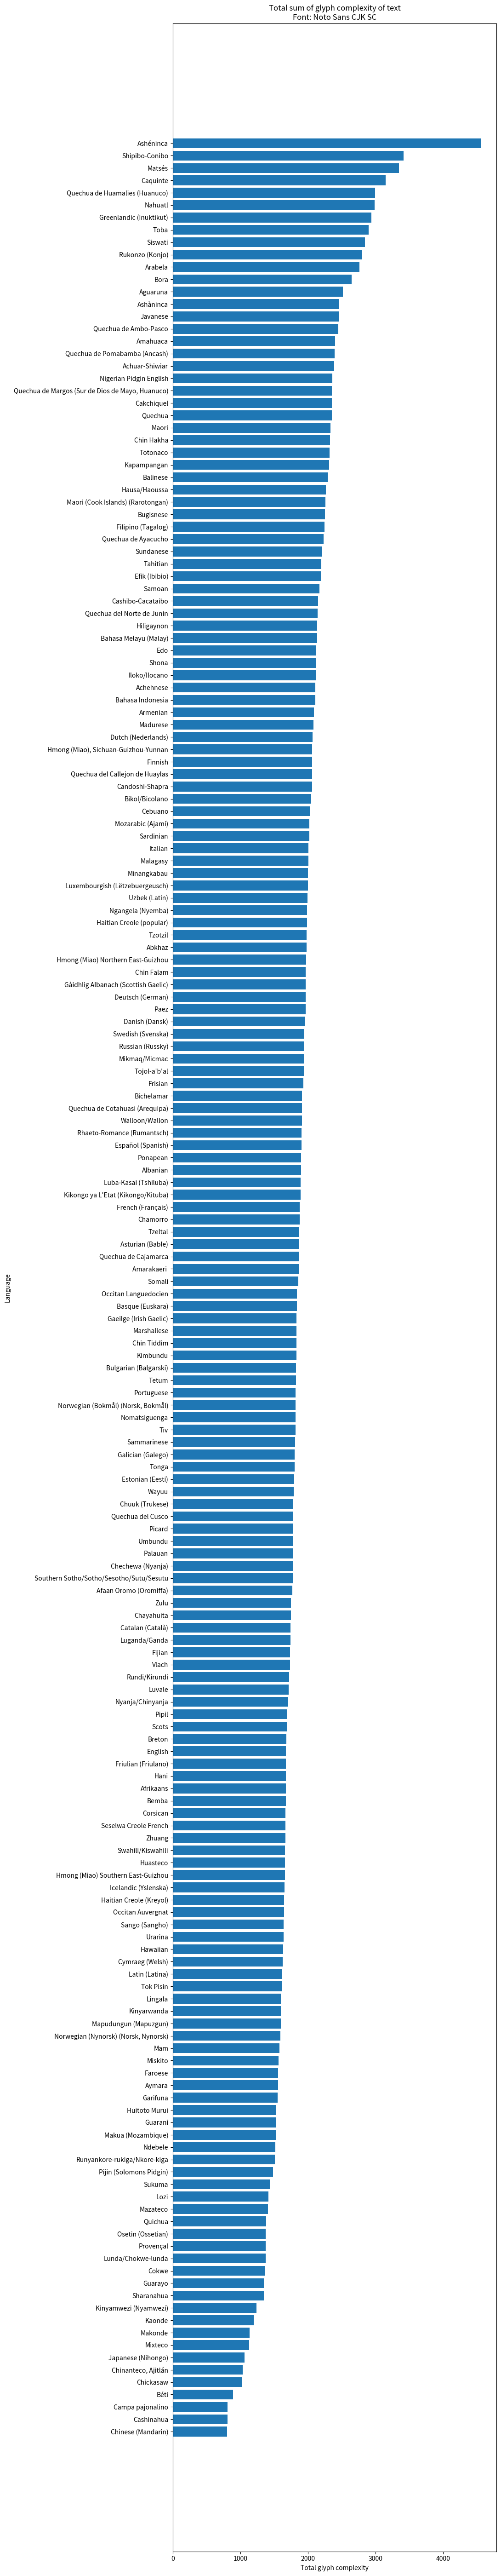

In [216]:
# ============================================================
# Compare TOTAL text complexity across all languages
#
# Total complexity =
#     sum of glyph complexity for every non-whitespace
#     character occurrence in the text.
#
# NO normalization.
#
# Uses font index 0 from analysis_fonts.
# Only texts with complete coverage for this font are included.
# ============================================================


font_index = 0

font_id = analysis_fonts[font_index]


# ------------------------------------------------------------
# Get font name
# ------------------------------------------------------------

font_name = (
    text_complexity[
        text_complexity["font_id"] == font_id
    ]["font_name"]
    .iloc[0]
)


# ------------------------------------------------------------
# Select this font
# ------------------------------------------------------------

plot_data = (
    text_complexity[
        text_complexity["font_id"] == font_id
    ]
    .sort_values(
        "total_complexity",
        ascending=True
    )
    .copy()
)


if plot_data.empty:

    raise ValueError(
        f"No usable text complexity data for "
        f"font_id {font_id}."
    )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(
        11,
        max(
            8,
            0.3 * len(plot_data)
        )
    )
)


plt.barh(
    plot_data["language_name"],
    plot_data["total_complexity"]
)


plt.xlabel(
    "Total glyph complexity"
)

plt.ylabel(
    "Language"
)

plt.title(
    f"Total sum of glyph complexity of text\n"
    f"Font: {font_name}"
)


plt.tight_layout()

plt.show()

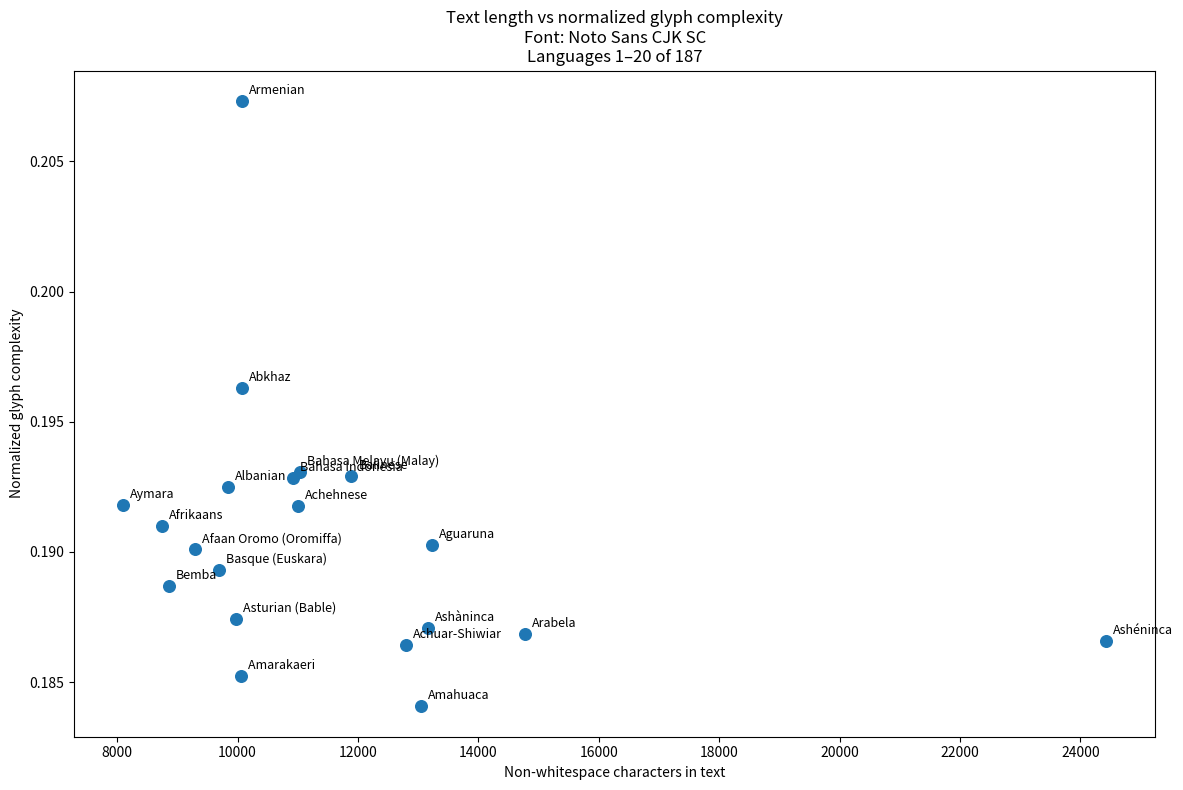

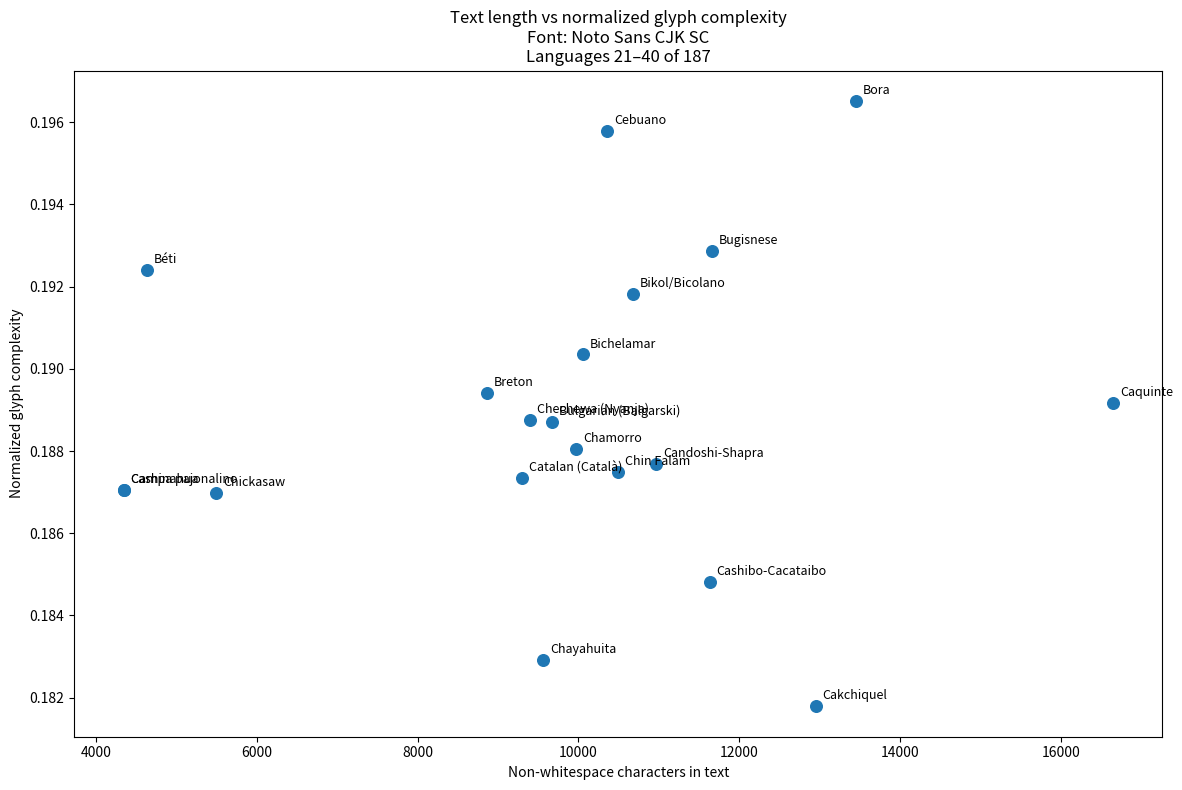

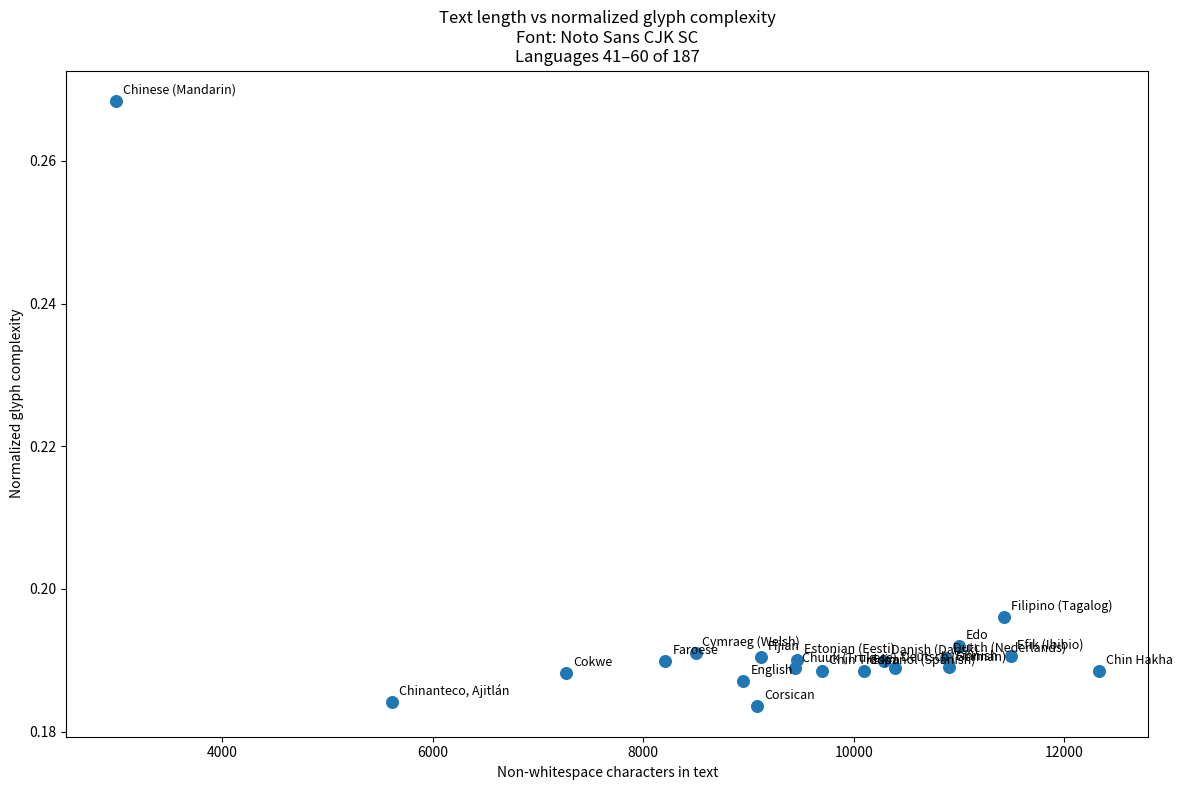

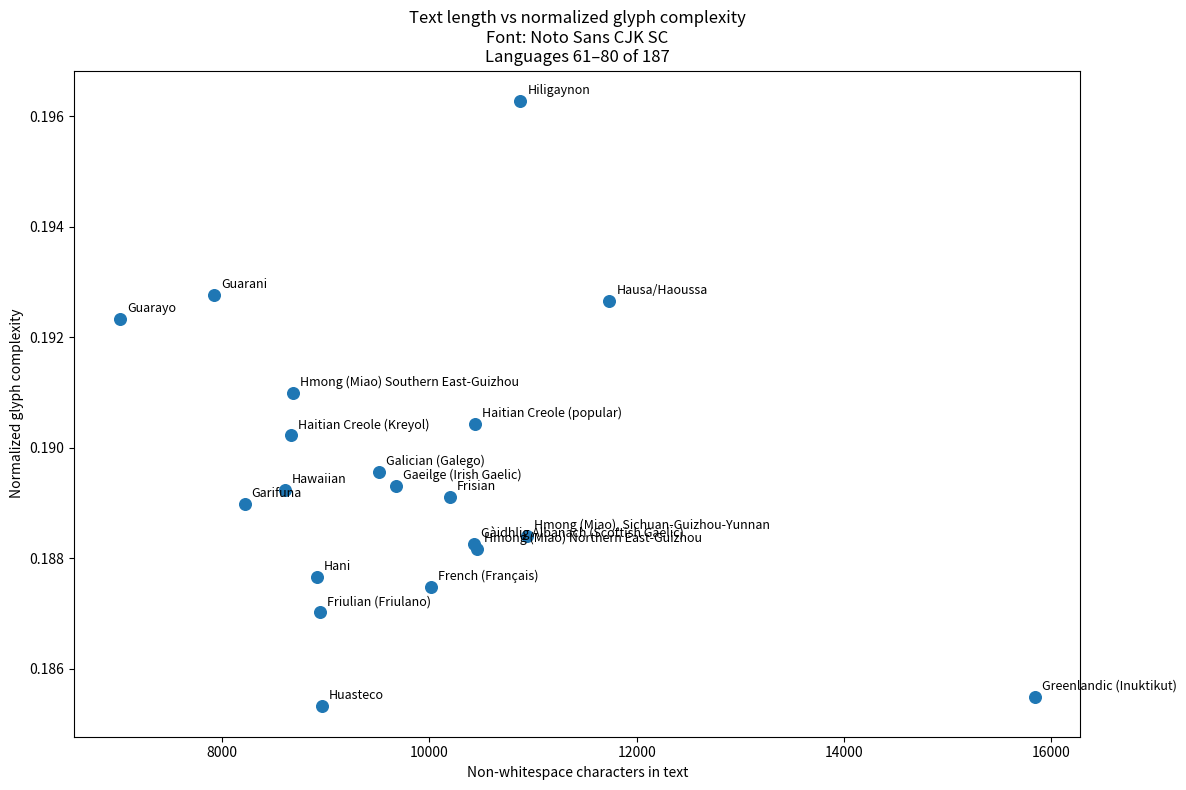

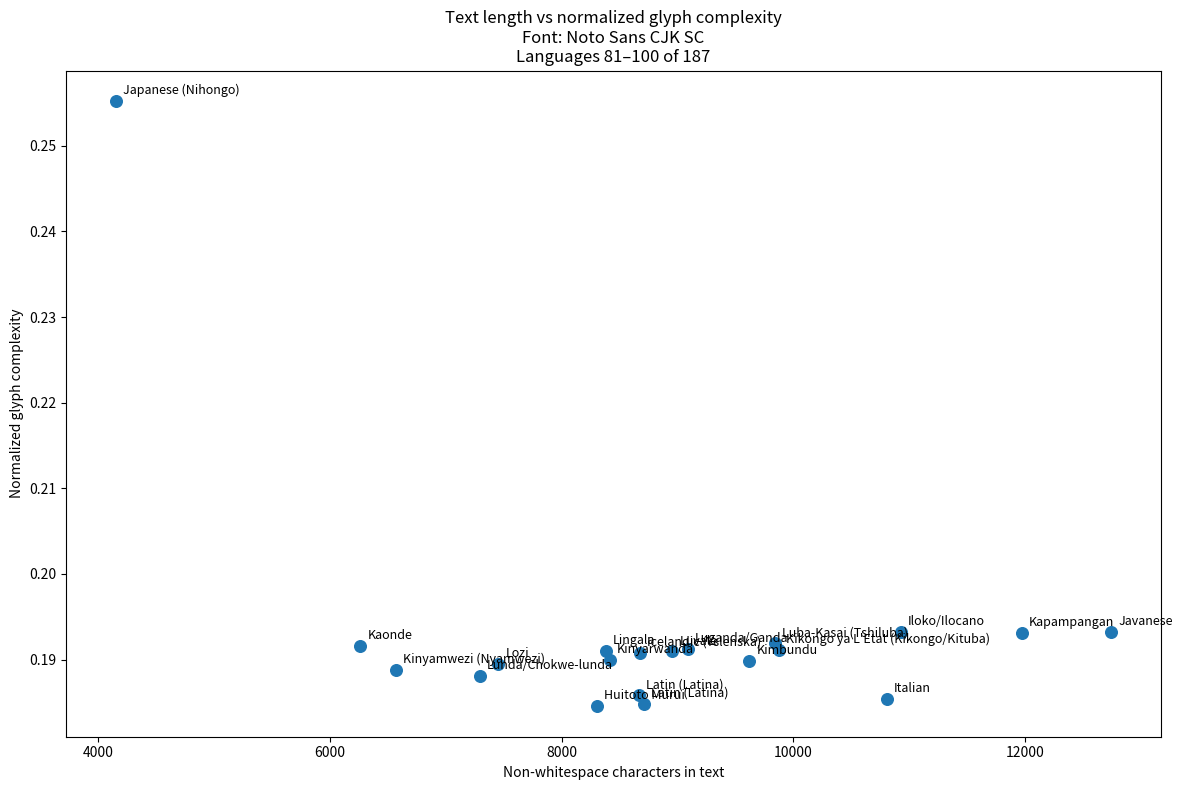

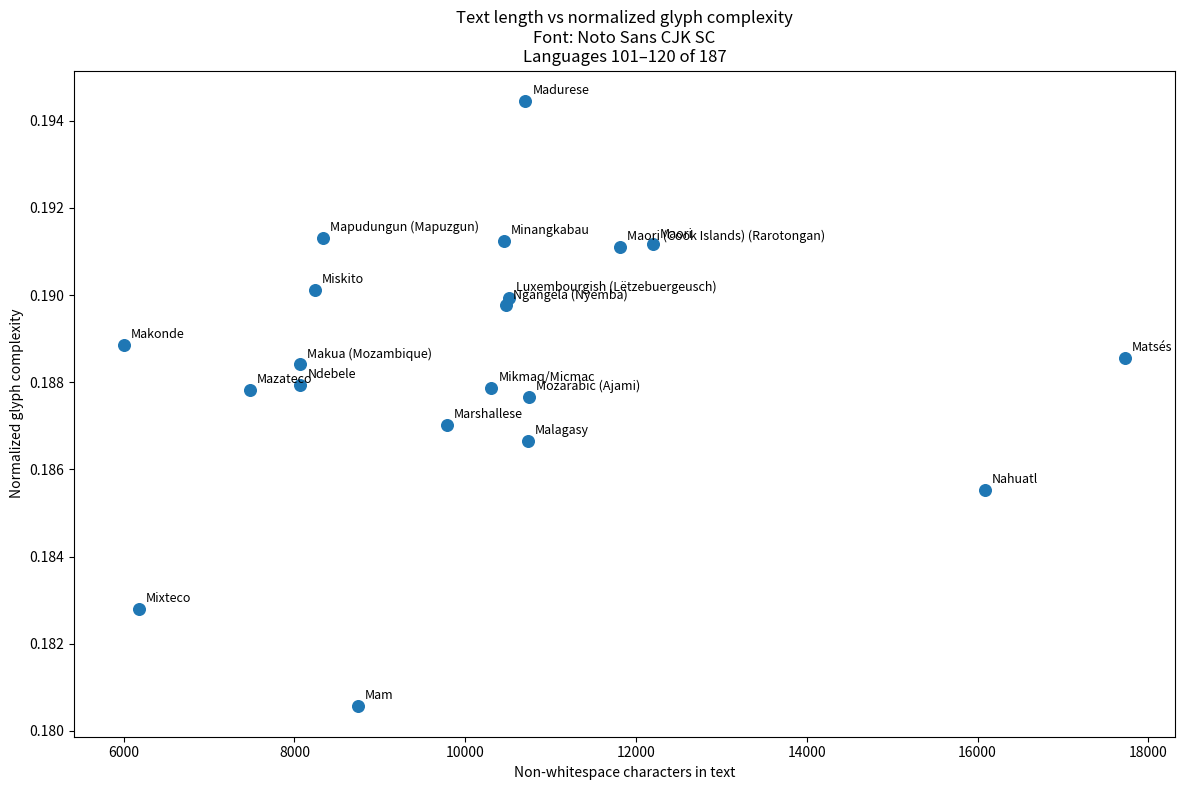

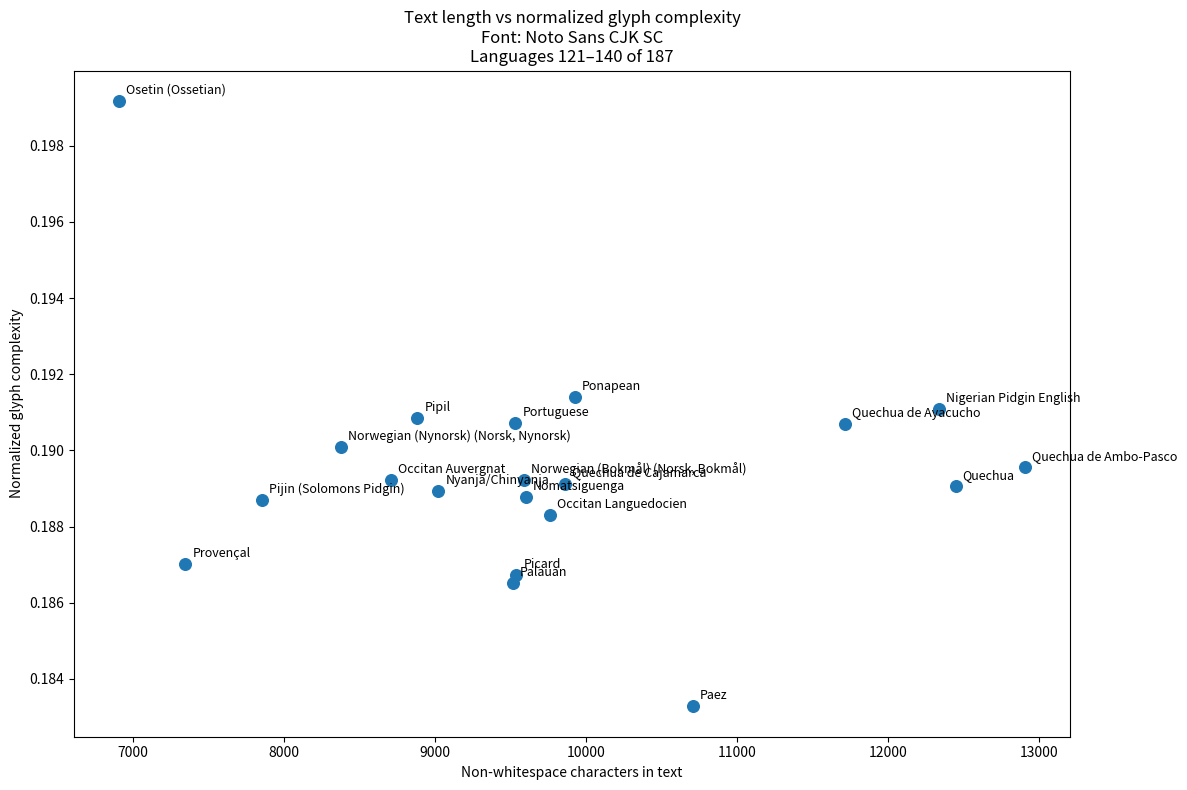

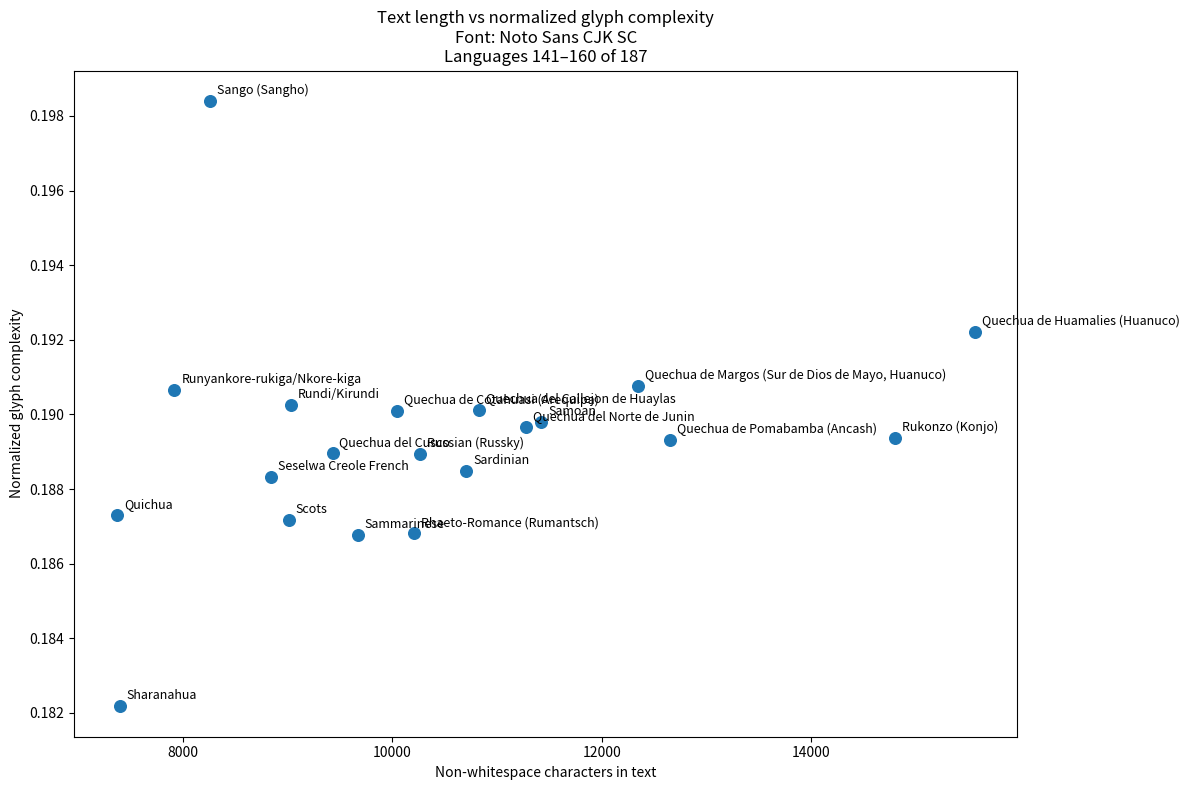

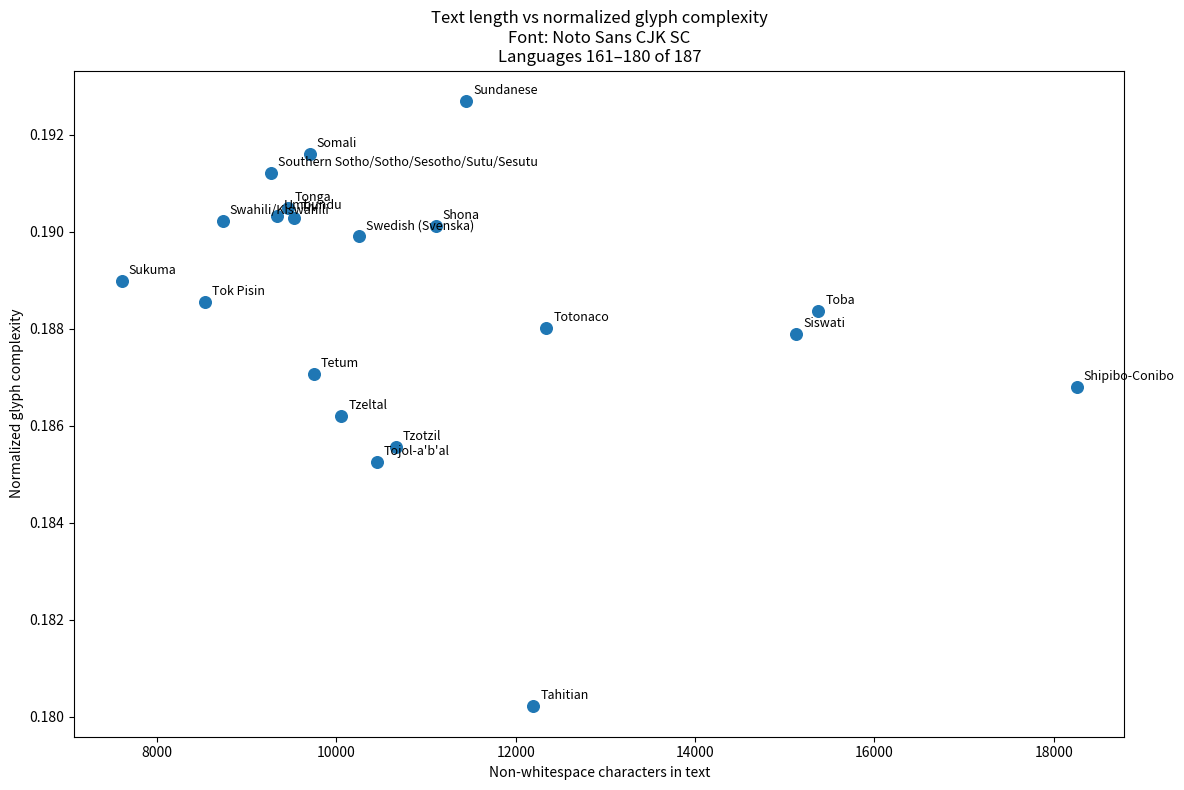

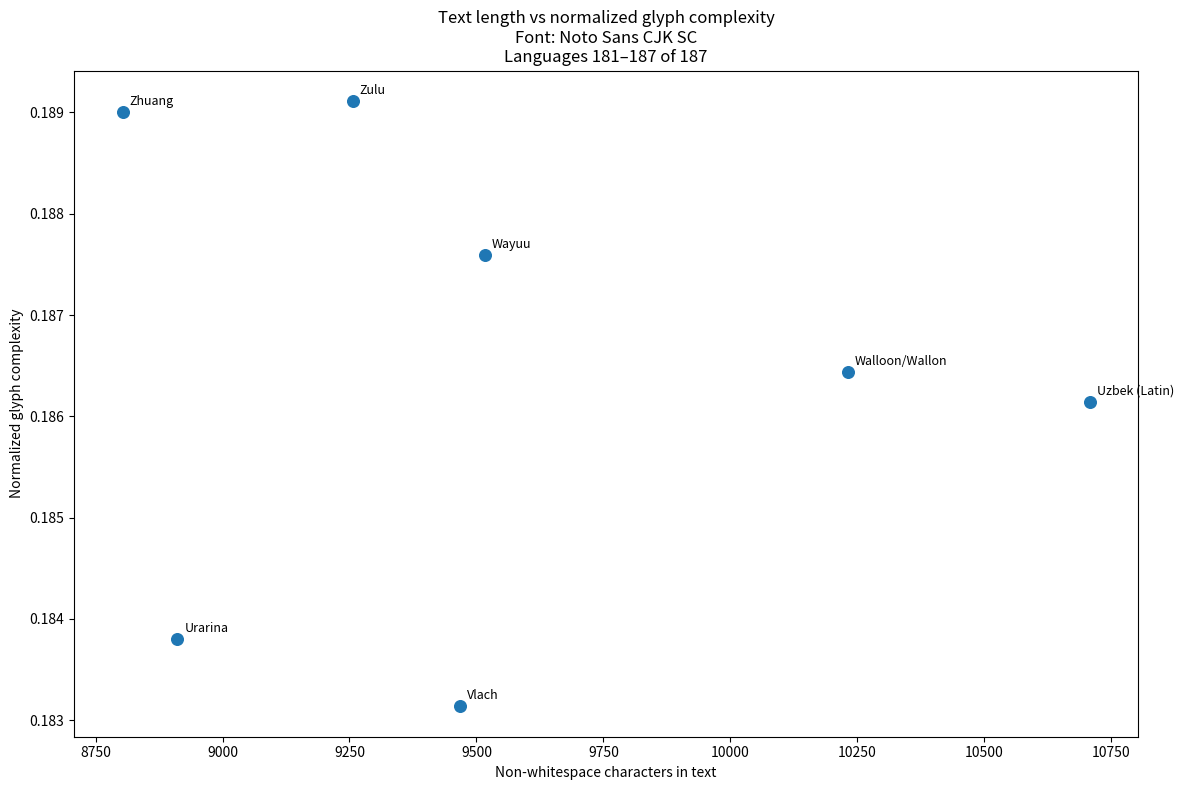

In [220]:
# ============================================================
# PLOT 2 — TEXT LENGTH vs NORMALIZED COMPLEXITY
#
# X axis:
#     Number of non-whitespace characters
#
# Y axis:
#     Normalized glyph complexity
#
# Each point = one language
#
# 20 languages per figure
# ============================================================

font_index = 0

font_id = analysis_fonts[font_index]


# ------------------------------------------------------------
# Get font name
# ------------------------------------------------------------

font_name = (
    text_complexity[
        text_complexity["font_id"] == font_id
    ]["font_name"]
    .iloc[0]
)


# ------------------------------------------------------------
# Select font
# ------------------------------------------------------------

plot_data = (
    text_complexity[
        text_complexity["font_id"] == font_id
    ]
    [
        [
            "language",
            "language_name",
            "nonwhitespace_characters",
            "normalized_complexity",
            "total_complexity"
        ]
    ]
    .copy()
    .sort_values("language_name")
    .reset_index(drop=True)
)


if plot_data.empty:

    raise ValueError(
        f"No usable data for font_id {font_id}."
    )


# ------------------------------------------------------------
# Split into groups of 20
# ------------------------------------------------------------

group_size = 20

number_of_groups = int(
    np.ceil(
        len(plot_data) / group_size
    )
)


for group_number in range(
    number_of_groups
):

    start = (
        group_number
        * group_size
    )

    end = (
        start
        + group_size
    )

    group = (
        plot_data
        .iloc[start:end]
        .copy()
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(
        figsize=(12, 8)
    )


    plt.scatter(
        group["nonwhitespace_characters"],
        group["normalized_complexity"],
        s=70
    )


    # --------------------------------------------------------
    # Label each point
    # --------------------------------------------------------

    for _, row in group.iterrows():

        plt.annotate(
            row["language_name"],
            (
                row["nonwhitespace_characters"],
                row["normalized_complexity"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )


    plt.xlabel(
        "Non-whitespace characters in text"
    )

    plt.ylabel(
        "Normalized glyph complexity"
    )


    plt.title(
        f"Text length vs normalized glyph complexity\n"
        f"Font: {font_name}\n"
        f"Languages {start + 1}–"
        f"{min(end, len(plot_data))} "
        f"of {len(plot_data)}"
    )


    plt.tight_layout()

    plt.show()

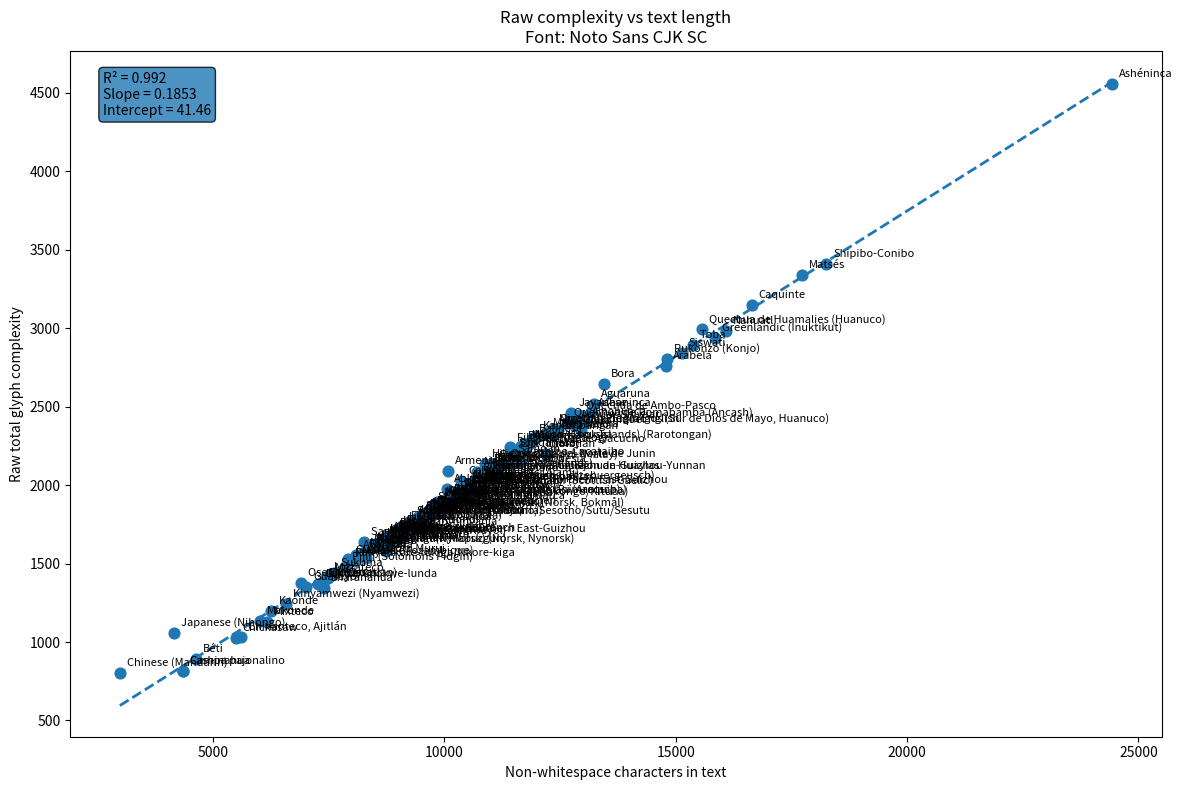

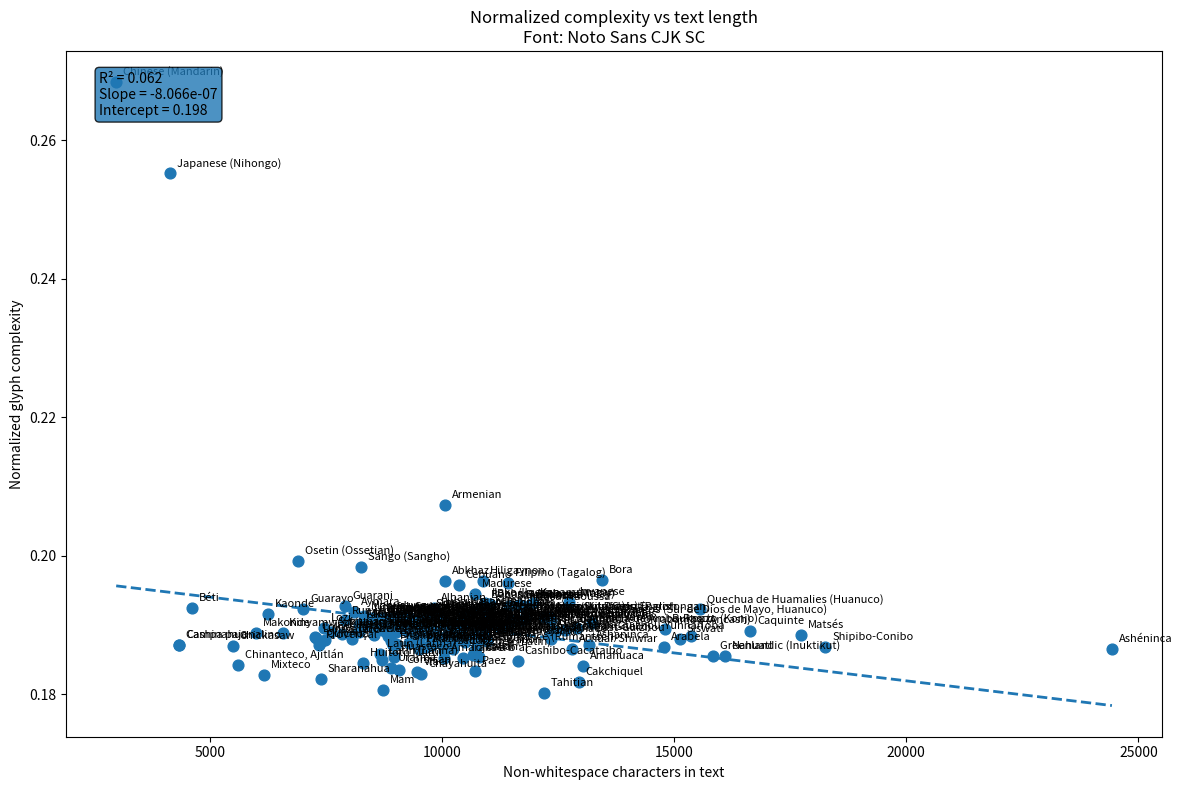


REGRESSION RESULTS

Font: Noto Sans CJK SC
Font ID: 2142

RAW COMPLEXITY vs TEXT LENGTH
  R²:        0.992204
  slope:     0.185304
  intercept: 41.4576
  p-value:   5.82246e-197

NORMALIZED COMPLEXITY vs TEXT LENGTH
  R²:        0.062119
  slope:     -8.06642e-07
  intercept: 0.198042
  p-value:   0.000582033


In [222]:
# How much of raw complexity is explained simply by how many characters the text contains?

# ============================================================
# TEXT LENGTH vs COMPLEXITY
#
# Plot 1:
#     Raw complexity vs text length
#
# Plot 2:
#     Normalized complexity vs text length
#
# Uses font index 0.
#
# Each point = one language.
# Only texts with complete coverage for this font are included.
# ============================================================

from scipy.stats import linregress


# ------------------------------------------------------------
# USER SETTING
# ------------------------------------------------------------

font_index = 0

font_id = analysis_fonts[font_index]


# ------------------------------------------------------------
# Get font name
# ------------------------------------------------------------

font_name = (
    text_complexity[
        text_complexity["font_id"] == font_id
    ]["font_name"]
    .iloc[0]
)


# ------------------------------------------------------------
# Select data
# ------------------------------------------------------------

plot_data = (
    text_complexity[
        text_complexity["font_id"] == font_id
    ]
    [
        [
            "language",
            "language_name",
            "nonwhitespace_characters",
            "total_complexity",
            "normalized_complexity"
        ]
    ]
    .dropna()
    .copy()
)


if plot_data.empty:

    raise ValueError(
        f"No usable data for font_id {font_id}."
    )


# ============================================================
# REGRESSION 1
#
# RAW COMPLEXITY vs TEXT LENGTH
# ============================================================

x = plot_data[
    "nonwhitespace_characters"
]

y = plot_data[
    "total_complexity"
]


reg_raw = linregress(
    x,
    y
)


plot_data["raw_predicted"] = (
    reg_raw.intercept
    +
    reg_raw.slope * x
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 8)
)


plt.scatter(
    x,
    y,
    s=60
)


# Regression line

x_line = np.linspace(
    x.min(),
    x.max(),
    200
)


y_line = (
    reg_raw.intercept
    +
    reg_raw.slope * x_line
)


plt.plot(
    x_line,
    y_line,
    linestyle="--",
    linewidth=2
)


# ------------------------------------------------------------
# Label languages
# ------------------------------------------------------------

for _, row in plot_data.iterrows():

    plt.annotate(
        row["language_name"],
        (
            row["nonwhitespace_characters"],
            row["total_complexity"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )


plt.xlabel(
    "Non-whitespace characters in text"
)

plt.ylabel(
    "Raw total glyph complexity"
)


plt.title(
    f"Raw complexity vs text length\n"
    f"Font: {font_name}"
)


# ------------------------------------------------------------
# Regression statistics
# ------------------------------------------------------------

stats_text = (
    f"R² = {reg_raw.rvalue ** 2:.3f}\n"
    f"Slope = {reg_raw.slope:.4g}\n"
    f"Intercept = {reg_raw.intercept:.4g}"
)


plt.text(
    0.03,
    0.97,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)


plt.tight_layout()

plt.show()


# ============================================================
# REGRESSION 2
#
# NORMALIZED COMPLEXITY vs TEXT LENGTH
# ============================================================

x = plot_data[
    "nonwhitespace_characters"
]

y = plot_data[
    "normalized_complexity"
]


reg_normalized = linregress(
    x,
    y
)


plot_data["normalized_predicted"] = (
    reg_normalized.intercept
    +
    reg_normalized.slope * x
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 8)
)


plt.scatter(
    x,
    y,
    s=60
)


# Regression line

x_line = np.linspace(
    x.min(),
    x.max(),
    200
)


y_line = (
    reg_normalized.intercept
    +
    reg_normalized.slope * x_line
)


plt.plot(
    x_line,
    y_line,
    linestyle="--",
    linewidth=2
)


# ------------------------------------------------------------
# Label languages
# ------------------------------------------------------------

for _, row in plot_data.iterrows():

    plt.annotate(
        row["language_name"],
        (
            row["nonwhitespace_characters"],
            row["normalized_complexity"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )


plt.xlabel(
    "Non-whitespace characters in text"
)

plt.ylabel(
    "Normalized glyph complexity"
)


plt.title(
    f"Normalized complexity vs text length\n"
    f"Font: {font_name}"
)


# ------------------------------------------------------------
# Regression statistics
# ------------------------------------------------------------

stats_text = (
    f"R² = {reg_normalized.rvalue ** 2:.3f}\n"
    f"Slope = {reg_normalized.slope:.4g}\n"
    f"Intercept = {reg_normalized.intercept:.4g}"
)


plt.text(
    0.03,
    0.97,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)


plt.tight_layout()

plt.show()


# ============================================================
# PRINT REGRESSION RESULTS
# ============================================================

print()
print("=" * 70)
print("REGRESSION RESULTS")
print("=" * 70)

print()
print(f"Font: {font_name}")
print(f"Font ID: {font_id}")

print()
print("RAW COMPLEXITY vs TEXT LENGTH")
print(
    f"  R²:        {reg_raw.rvalue ** 2:.6f}"
)
print(
    f"  slope:     {reg_raw.slope:.6g}"
)
print(
    f"  intercept: {reg_raw.intercept:.6g}"
)
print(
    f"  p-value:   {reg_raw.pvalue:.6g}"
)

print()
print("NORMALIZED COMPLEXITY vs TEXT LENGTH")
print(
    f"  R²:        {reg_normalized.rvalue ** 2:.6f}"
)
print(
    f"  slope:     {reg_normalized.slope:.6g}"
)
print(
    f"  intercept: {reg_normalized.intercept:.6g}"
)
print(
    f"  p-value:   {reg_normalized.pvalue:.6g}"
)